In [2]:
import datetime
import os
import re
import statistics
import sys
import scanpy as sc
from decimal import Decimal
from multiprocessing import Pool
import itertools
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from skbio.stats.composition import clr

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
import warnings

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.font_manager as fm
mpl.rcParams['pdf.fonttype'] = 42
fm.fontManager.addfont("fonts/arial.ttf")
mpl.rcParams['font.family'] = 'arial'
mpl.rcParams['lines.linewidth'] = 0.5

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
def filename_cell_type(filename):
    cell_type = re.sub(" ", "_", filename)
    cell_type = re.sub("[+]", "pos", cell_type)
    cell_type = re.sub("[-]", "_", cell_type)
    cell_type = re.sub("[/]", "_", cell_type)
    return cell_type

In [4]:
obj_path = "/home/liyanguo/MyImmuCell/06_Finnal_raw_count/"

# 临床信息整理

In [12]:
Clinical_info = pd.read_excel(
    "/home/liyanguo/MyImmuCell/03_clinical/Clinical_data.xlsx", skiprows=1
)

In [13]:
Clinical_info.shape

(994, 53)

In [14]:
Sample_info = pd.read_excel(
    "/home/liyanguo/MyImmuCell/03_clinical/Suppl.xlsx", sheet_name="Table 2"
)

In [15]:
Sample_info.shape

(1988, 33)

In [16]:
info = pd.merge(Sample_info, Clinical_info, on="ClinicalID", how="left")

In [17]:
info.columns

Index(['样本编号', 'CITE-seq RNA file name', 'CITE-seq ADT file name',
       'TCR file name', 'BCR file name', 'WES/WGS sample name',
       'Olink sample name', '公司样本名', '送样日期', '到样日期', 'D送样日期', 'R到样日期', '身份证号',
       '姓名', '签到表性别', '签到表年龄', '昼夜节律', 'DonorID', 'SampleID', 'ClinicalID',
       'Batch', 'Sequencing_platform', 'Sequencing_Strategy', 'Species ',
       'Disease State',
       'Sample_Type (Equal numbers of cells from PBMC and WB suspension were pooled together)',
       'Suspension_type', 'Gender_x', 'Pregnancy', 'Pregnancy stage',
       'Sampling time', 'Datelanded', 'Datereceived', 'ID', 'ID2', 'Hospital',
       'Name', 'Gender_y', 'Age_clinical', 'WBC', 'NEUT%', 'LYMPH%', 'MONO%',
       'EOS%', 'BASO%', 'NEUT#', 'LYMPH#', 'MONO#', 'EOS#', 'BASO#', 'RBC',
       'MCV', 'RDW-CV', 'HCT', 'HGB', 'MCH', 'MCHC', 'PLT', 'PCT', 'PDW',
       'MPV', 'AST', 'ALT', 'AST:ALT', 'GGT', 'CEA', 'AFP', 'ALB', 'GLB',
       'A:G', 'TP', 'TBIL', 'DBIL', 'IBIL', 'ALP', 'TC', 'TG', 'HDL-C

In [18]:
all(info["Gender_x"] == info["Gender_y"])

True

In [19]:
all(info["姓名"] == info["Name"])

True

In [20]:
all(info["身份证号"] == info["ID2"])

True

In [21]:
info.rename(columns={"Gender_x": "Gender"}, inplace=True)

In [22]:
info = info[['身份证号', '姓名','DonorID', 'SampleID',
       'ClinicalID', 'Batch', 'Gender', 'Pregnancy', 'Pregnancy stage',
       'Sampling time', 'Datelanded', 'Datereceived',
       'Name', 'Age_clinical', 'WBC', 'NEUT%',
       'LYMPH%', 'MONO%', 'EOS%', 'BASO%', 'NEUT#', 'LYMPH#', 'MONO#', 'EOS#',
       'BASO#', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW-CV', 'PLT',
       'PCT', 'PDW', 'MPV', 'AST', 'ALT', 'AST:ALT', 'GGT', 'CEA', 'AFP',
       'ALB', 'GLB', 'A:G', 'TP', 'TBIL', 'DBIL', 'IBIL', 'ALP', 'TC', 'TG',
       'HDL-C', 'LDL-C', 'Cr', 'UREA', 'UA', 'BMI', 'Glucose', 'Desease']]

## 计算年龄

In [23]:
# 我们存在一个人多个样本的情况, 例如不同时期的怀孕个体，样本所对应的年龄不同，这里可以正确处理，后需要注意，部分分析内容不能只使用个体，个体只有一个年龄信息

In [4]:
def calculate_age(ID_Card, Datelanded):
    # Birthday
    birth_year = int(ID_Card[6:10])
    birth_month = int(ID_Card[10:12])
    birth_day = int(ID_Card[12:14])
    birth_date = datetime.date(birth_year, birth_month, birth_day)

    # Calculate the total number of months between the two dates
    years_diff = Datelanded.year - birth_date.year
    months_diff = Datelanded.month - birth_date.month

    # Adjust if the current month is earlier than the birth month
    Age_in_Months = years_diff * 12 + months_diff

    # If the birth day hasn't occurred yet this month, subtract 1
    if Datelanded.day < birth_date.day:
        Age_in_Months -= 1
    Age_in_Years = round(Decimal(Age_in_Months / 12), 1)
    return Age_in_Months, Age_in_Years

In [25]:
data = info.apply(lambda row: calculate_age(row["身份证号"], row["Datelanded"]), axis=1)

In [26]:
info["Age_in_Months"] = [y[0] for y in data]
info["Age_in_Years"] = [y[1] for y in data]

In [27]:
info["Ten_year_intervals"] = pd.cut(
    info["Age_in_Years"],
    bins=[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 110],
    right=False,
    labels=[
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ],
)
info["Ten_year_intervals"].value_counts()

Ten_year_intervals
80-89    324
70-79    286
30-39    256
60-69    250
40-49    176
90+      168
20-29    166
10-19    136
50-59    118
2-9      108
Name: count, dtype: int64

In [28]:
info["Five_year_intervals"] = pd.cut(
    info["Age_in_Years"],
    bins=[
        1,
        5,
        10,
        15,
        20,
        25,
        30,
        35,
        40,
        45,
        50,
        55,
        60,
        65,
        70,
        75,
        80,
        85,
        90,
        95,
        110,
    ],
    right=False,
    labels=[
        "2-4",
        "5-9",
        "10-14",
        "15-19",
        "20-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80-84",
        "85-89",
        "90-94",
        "95+",
    ],
)
info["Five_year_intervals"].value_counts()

Five_year_intervals
80-84    218
70-74    180
65-69    150
30-34    130
35-39    126
90-94    124
25-29    120
40-44    108
85-89    106
75-79    106
60-64    100
5-9       88
10-14     72
50-54     72
45-49     68
15-19     64
55-59     46
20-24     46
95+       44
2-4       20
Name: count, dtype: int64

In [29]:
info["Simplified_intervals"] = pd.cut(
    info["Age_in_Years"],
    bins=[2, 10, 19, 39, 59, 79, 110],
    right=False,
    labels=[
        "Childhood(2-9)",
        "Adolescence(10-19)",
        "Young adulthood(20-39)",
        "Middle adulthood(40-60)",
        "Older adulthood(60-79)",
        "Longevity(80+)",
    ],
)
info["Simplified_intervals"].value_counts()

Simplified_intervals
Older adulthood(60-79)     524
Longevity(80+)             506
Young adulthood(20-39)     418
Middle adulthood(40-60)    310
Adolescence(10-19)         122
Childhood(2-9)             108
Name: count, dtype: int64

In [ ]:
# 8个人的年龄
x =  pd.read_excel(
    "/home/liyanguo/MyImmuCell/Suppl-8.xlsx"
)

data = x.apply(lambda row: calculate_age(row["身份证号"], row["Datelanded"]), axis=1)

x["Age_in_Months"] = [y[0] for y in data]
x["Age_in_Years"] = [y[1] for y in data]
x.to_csv("/home/liyanguo/MyImmuCell/Suppl-8a.csv")

## 计算五分类的百分比

In [30]:
Absolute_counts_label = ["NEUT#", "LYMPH#", "MONO#", "EOS#", "BASO#"]

In [31]:
info["WBC_recalc"] = info[Absolute_counts_label].sum(axis=1)

In [32]:
info["NEUT%_recalc"] = (info["NEUT#"] / info["WBC_recalc"] * 100).round(2)
info["LYMPH%_recalc"] = (info["LYMPH#"] / info["WBC_recalc"] * 100).round(2)
info["MONO%_recalc"] = (info["MONO#"] / info["WBC_recalc"] * 100).round(2)
info["EOS%_recalc"] = (info["EOS#"] / info["WBC_recalc"] * 100).round(2)
info["BASO%_recalc"] = (info["BASO#"] / info["WBC_recalc"] * 100).round(2)

## 保存

In [33]:
info.to_excel(
    f"/home/liyanguo/MyImmuCell/03_clinical/info_{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}.xlsx"
)

# 统计细胞比例数据

In [4]:
Final_cell_labels = pd.read_csv(
    "/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Final_cell_label.csv",
    index_col=0,
)
Final_cell_labels.shape

(51898839, 7)

## 合并anndata obs得到样本之类信息

In [5]:
Full_dataset_scRNA_count_HVG = sc.read_h5ad(
    "/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/Full_dataset_scRNA_count_HVG.h5ad",
    backed="r",
)
Full_dataset_scRNA_count_HVG

AnnData object with n_obs × n_vars = 51898839 × 2000 backed at '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/Full_dataset_scRNA_count_HVG.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [6]:
Final_cell_labels = Final_cell_labels.join(Full_dataset_scRNA_count_HVG.obs, how="left")
Final_cell_labels.shape

(51898839, 42)

In [7]:
Full_dataset_scRNA_count_HVG.file.close

<bound method AnnDataFileManager.close of Backing file manager of file /home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/Full_dataset_scRNA_count_HVG.h5ad.>

## 分类PBMC和Neu

In [8]:
# Platelets not included in composition analysis
Final_cell_labels = Final_cell_labels.query('Classification_L3 != "Platelets"').copy()

In [9]:
Final_cell_labels["lineage"] = np.where(
    Final_cell_labels["Classification_L3"].isin(["NDNs", "Basophils"]),
    "NDN_BAS",
    "PBMC",
)

## 读入临床信息

In [10]:
Clinical_info = pd.read_excel(
    "/home/liyanguo/MyImmuCell/03_clinical/info_2025-11-01 16:11:22.xlsx", index_col=0
)

In [11]:
Clinical_info = Clinical_info[['DonorID', 'SampleID', 'ClinicalID', 'Batch', 'Gender',
            'Pregnancy', 'Pregnancy stage', 'Sampling time',
            'Age_in_Months', 'Age_in_Years', 'Ten_year_intervals',
            'Five_year_intervals', 'Simplified_intervals',
            'WBC_recalc','NEUT%_recalc', 'LYMPH%_recalc', 'MONO%_recalc', 'EOS%_recalc',
            'BASO%_recalc','NEUT#', 'LYMPH#', 'MONO#', 'EOS#', 'BASO#',
            'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW-CV', 'PLT', 'PCT',
            'PDW', 'MPV', 'AST', 'ALT', 'AST:ALT', 'GGT', 'CEA', 'AFP', 'ALB',
            'GLB', 'A:G', 'TP', 'TBIL', 'DBIL', 'IBIL', 'ALP', 'TC', 'TG', 'HDL-C',
            'LDL-C', 'Cr', 'UREA', 'UA','Glucose', 'BMI', 
            ]]

In [12]:
Final_cell_labels[~Final_cell_labels["SampleID"].isin(Clinical_info["SampleID"])][
    "SampleID"
].unique()

[], Categories (1988, object): ['D0009_Rep1', 'D0009_Rep2', 'D0010_Rep1', 'D0010_Rep2', ..., 'D0957_Rep1', 'D0957_Rep2', 'D0958_Rep1', 'D0958_Rep2']

In [13]:
len(Final_cell_labels["SampleID"].astype(str).unique())

1988

In [14]:
len(Clinical_info["SampleID"].unique())

1988

## Function of calc_counts_and_frac

In [15]:
Final_cell_labels["lineage"].value_counts()

lineage
NDN_BAS    28349093
PBMC       23542318
Name: count, dtype: int64

In [16]:
Final_cell_labels = pd.merge(Final_cell_labels,Clinical_info,on='SampleID',how='left')

In [17]:
def calc_counts_and_frac(data, lineage, groupby, sample_or_donor):
    """返回绝对计数表 + 百分比表"""
    sub = data.loc[data["lineage"] == lineage, :].copy()
    sample_counts = (
        sub.groupby(sample_or_donor).size().reset_index(name=f"{sample_or_donor}_{lineage}_count")
    )

    # 计数
    level_counts = (
        sub.groupby([groupby, sample_or_donor]).size().reset_index(name=f"{groupby}_count")
    )
    pivot_level_counts = level_counts.pivot_table(
        index=sample_or_donor,
        columns=groupby,
        values=f"{groupby}_count",
        fill_value=0,
        aggfunc='sum' # only one value to aggregate
    ).reset_index()
    pivot_level_counts.rename(
        columns={col: f"{col}#" for col in pivot_level_counts.columns[1:]}, inplace=True
    )

    # 比例计算
    merged = pd.merge(level_counts, sample_counts, on=sample_or_donor, how="left")
    merged[f"{groupby}_frac_{lineage}"] = (
        merged[f"{groupby}_count"] / merged[f"{sample_or_donor}_{lineage}_count"] * 100
    )
    pivot_frac = (
        merged.pivot_table(
            index=sample_or_donor,
            columns=groupby,
            values=f"{groupby}_frac_{lineage}",
            fill_value=0,
            # aggfunc="sum",# only one value to aggregate
        )
        .reset_index()
        .round(2)
    )
    pivot_frac.rename(
        columns={col: f"{col}%_in_{lineage}" for col in pivot_frac.columns[1:]},
        inplace=True,
    )

    return sample_counts, pivot_level_counts, pivot_frac

## Classification_L4

In [18]:
groupby = "Classification_L4"

### sample Level

In [19]:
# 比例表
sample_counts_PBMC, pivot_level_counts_PBMC, pivot_frac_PBMC = calc_counts_and_frac(
    Final_cell_labels, lineage="PBMC", groupby=groupby,sample_or_donor = 'SampleID'
)
sample_counts_NDN_BAS, pivot_level_counts_NDN_BAS, pivot_frac_NDN_BAS =calc_counts_and_frac(
    Final_cell_labels, lineage="NDN_BAS", groupby=groupby,sample_or_donor = 'SampleID'
)

In [20]:
sample_total_counts = (
    Final_cell_labels.groupby("SampleID")
    .size()
    .reset_index(name="Sample_total_cell_counts")
)

In [21]:
counts_frac_clinicl = (
    sample_total_counts.merge(sample_counts_PBMC, on="SampleID", how="left")
    .merge(sample_counts_NDN_BAS, on="SampleID", how="left")
    .merge(pivot_level_counts_PBMC, on="SampleID", how="left")
    .merge(pivot_frac_PBMC, on="SampleID", how="left")
    .merge(pivot_level_counts_NDN_BAS, on="SampleID", how="left")
    .merge(pivot_frac_NDN_BAS, on="SampleID", how="left")
    .merge(Clinical_info, on="SampleID", how="left")
)

In [22]:
counts_frac_clinicl.to_excel(f"{obj_path}{groupby}_sample_counts_frac_clinicl_table.xlsx")

### Donor Level

In [23]:
# 比例表
sample_counts_PBMC, pivot_level_counts_PBMC, pivot_frac_PBMC = calc_counts_and_frac(
    Final_cell_labels, lineage="PBMC", groupby=groupby,sample_or_donor = 'ClinicalID'
)
sample_counts_NDN_BAS, pivot_level_counts_NDN_BAS, pivot_frac_NDN_BAS =calc_counts_and_frac(
    Final_cell_labels, lineage="NDN_BAS", groupby=groupby,sample_or_donor = 'ClinicalID'
)

In [24]:
donor_total_counts = (
    Final_cell_labels.groupby("ClinicalID")
    .size()
    .reset_index(name="Donor_total_cell_counts")
)

In [25]:
counts_frac_clinicl = (
    donor_total_counts.merge(sample_counts_PBMC, on="ClinicalID", how="left")
    .merge(sample_counts_NDN_BAS, on="ClinicalID", how="left")
    .merge(pivot_level_counts_PBMC, on="ClinicalID", how="left")
    .merge(pivot_frac_PBMC, on="ClinicalID", how="left")
    .merge(pivot_level_counts_NDN_BAS, on="ClinicalID", how="left")
    .merge(pivot_frac_NDN_BAS, on="ClinicalID", how="left")
    .merge(Clinical_info.drop(['SampleID'],axis=1).drop_duplicates(), on="ClinicalID", how="left")
)

In [26]:
counts_frac_clinicl.to_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx")

### Plot

In [4]:
groupby = "Classification_L4"
counts_frac_clinicl = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [5]:
# 统计检验
def quick_stat_test(data, plt_x, plt_y):
    groups = data[plt_x].dropna().unique()
    stats_data = [data[data[plt_x] == g][plt_y] for g in groups]
    if len(groups) == 2:
        t_stat, p_val = stats.ttest_ind(*stats_data, equal_var=False)
        return f"T-test: t={t_stat:.2f}, P={p_val:.4g}"
    elif len(groups) > 2:
        if data[plt_y].nunique() != 1:
            h_stat, p_val = stats.kruskal(*stats_data)
            return f"Kruskal-Wallis: H={h_stat:.2f}, P={p_val:.4g}"
    else:
        return "NA"

In [6]:
plt_x_list = [
    "Ten_year_intervals",
    "Five_year_intervals",
    "Simplified_intervals",
    "Pregnancy stage",
    "Sampling time",
    "Gender",
]
order_dict = {
    "Ten_year_intervals": [
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ],
    "Five_year_intervals": [
        "2-4",
        "5-9",
        "10-14",
        "15-19",
        "20-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80-84",
        "85-89",
        "90-94",
        "95+",
    ],
    "Simplified_intervals": [
        "Childhood(2-9)",
        "Adolescence(10-19)",
        "Young adulthood(20-39)",
        "Middle adulthood(40-60)",
        "Older adulthood(60-79)",
        "Longevity(80+)",
    ],
    "Pregnancy stage": [
        "First trimester",
        "Second trimester",
        "Third trimester",
        "Parturition",
    ],
    "Sampling time": ["Morning", "Evening"],
    "Gender": ["Female", "Male"],
}

In [7]:
plt_y_list_celltype = counts_frac_clinicl.columns[
    counts_frac_clinicl.columns.str.contains(r"_in_")
]

In [8]:
def plot_box_strip(data, x, y, order, outpath):
    if data[y].dropna().empty:
        return
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(
        x=x,
        y=y,
        data=data,
        order=order,
        palette="pastel",
        width=0.7,
        linewidth=0,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        x=x,
        y=y,
        data=data,
        order=order,
        color="black",
        alpha=0.3,
        jitter=0.1,
        size=2,
        ax=ax,
    )
    ax.set_title(quick_stat_test(data, x, y), fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close()

In [9]:
mask = (
            (counts_frac_clinicl["ClinicalID"].str.contains("_E"))
            | (counts_frac_clinicl["Pregnancy"]== "YES")
        )

In [10]:
# Cell type
for plt_x in plt_x_list:
    if plt_x == "Pregnancy stage":
        mask = counts_frac_clinicl["Pregnancy"]== "YES"
        plot_data = counts_frac_clinicl[mask]
    elif plt_x == "Sampling time":
        mask = counts_frac_clinicl["ClinicalID"].str.contains("_M|_E")
        plot_data = counts_frac_clinicl[mask]
    else:
        mask = (
            (counts_frac_clinicl["ClinicalID"].str.contains("_E"))
            | (counts_frac_clinicl["Pregnancy"]== "YES")
        )
        plot_data = counts_frac_clinicl[~mask]

    for plt_y in plt_y_list_celltype:
        fig_dir = f"/home/liyanguo/MyImmuCell/08_supp_outputs/Age_group_Frac/{groupby}/cell_type/{plt_x}"
        os.makedirs(fig_dir, exist_ok=True)
        outpath = f"{fig_dir}/{filename_cell_type(plt_y)}.pdf"
        data = plot_data[[plt_x, plt_y]].dropna()
        plot_box_strip(data, plt_x, plt_y, order_dict.get(plt_x, None), outpath)

## Classification_L3

In [34]:
groupby = "Classification_L3"

### sample Level

In [35]:
# 比例表
sample_counts_PBMC, pivot_level_counts_PBMC, pivot_frac_PBMC = calc_counts_and_frac(
    Final_cell_labels, lineage="PBMC", groupby=groupby,sample_or_donor = 'SampleID'
)
sample_counts_NDN_BAS, pivot_level_counts_NDN_BAS, pivot_frac_NDN_BAS =calc_counts_and_frac(
    Final_cell_labels, lineage="NDN_BAS", groupby=groupby,sample_or_donor = 'SampleID'
)

In [36]:
sample_total_counts = (
    Final_cell_labels.groupby("SampleID")
    .size()
    .reset_index(name="Sample_total_cell_counts")
)

In [37]:
counts_frac_clinicl = (
    sample_total_counts.merge(sample_counts_PBMC, on="SampleID", how="left")
    .merge(sample_counts_NDN_BAS, on="SampleID", how="left")
    .merge(pivot_level_counts_PBMC, on="SampleID", how="left")
    .merge(pivot_frac_PBMC, on="SampleID", how="left")
    .merge(pivot_level_counts_NDN_BAS, on="SampleID", how="left")
    .merge(pivot_frac_NDN_BAS, on="SampleID", how="left")
    .merge(Clinical_info, on="SampleID", how="left")
)

In [38]:
counts_frac_clinicl.to_excel(f"{obj_path}{groupby}_sample_counts_frac_clinicl_table.xlsx")

### Donor Level

In [39]:
# 比例表
sample_counts_PBMC, pivot_level_counts_PBMC, pivot_frac_PBMC = calc_counts_and_frac(
    Final_cell_labels, lineage="PBMC", groupby=groupby,sample_or_donor = 'ClinicalID'
)
sample_counts_NDN_BAS, pivot_level_counts_NDN_BAS, pivot_frac_NDN_BAS =calc_counts_and_frac(
    Final_cell_labels, lineage="NDN_BAS", groupby=groupby,sample_or_donor = 'ClinicalID'
)

In [40]:
donor_total_counts = (
    Final_cell_labels.groupby("ClinicalID")
    .size()
    .reset_index(name="Donor_total_cell_counts")
)

In [41]:
counts_frac_clinicl = (
    donor_total_counts.merge(sample_counts_PBMC, on="ClinicalID", how="left")
    .merge(sample_counts_NDN_BAS, on="ClinicalID", how="left")
    .merge(pivot_level_counts_PBMC, on="ClinicalID", how="left")
    .merge(pivot_frac_PBMC, on="ClinicalID", how="left")
    .merge(pivot_level_counts_NDN_BAS, on="ClinicalID", how="left")
    .merge(pivot_frac_NDN_BAS, on="ClinicalID", how="left")
    .merge(Clinical_info.drop(['SampleID'],axis=1).drop_duplicates(), on="ClinicalID", how="left")
)

In [42]:
counts_frac_clinicl.to_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx")

### Plot

In [43]:
groupby = "Classification_L3"
counts_frac_clinicl = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [44]:
# 统计检验
def quick_stat_test(data, plt_x, plt_y):
    groups = data[plt_x].dropna().unique()
    stats_data = [data[data[plt_x] == g][plt_y] for g in groups]
    if len(groups) == 2:
        t_stat, p_val = stats.ttest_ind(*stats_data, equal_var=False)
        return f"T-test: t={t_stat:.2f}, P={p_val:.4g}"
    elif len(groups) > 2:
        if data[plt_y].nunique() != 1:
            h_stat, p_val = stats.kruskal(*stats_data)
            return f"Kruskal-Wallis: H={h_stat:.2f}, P={p_val:.4g}"
    else:
        return "NA"

In [45]:
plt_x_list = [
    "Ten_year_intervals",
    "Five_year_intervals",
    "Simplified_intervals",
    "Pregnancy stage",
    "Sampling time",
    "Gender",
]
order_dict = {
    "Ten_year_intervals": [
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ],
    "Five_year_intervals": [
        "2-4",
        "5-9",
        "10-14",
        "15-19",
        "20-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80-84",
        "85-89",
        "90-94",
        "95+",
    ],
    "Simplified_intervals": [
        "Childhood(2-9)",
        "Adolescence(10-19)",
        "Young adulthood(20-39)",
        "Middle adulthood(40-60)",
        "Older adulthood(60-79)",
        "Longevity(80+)",
    ],
    "Pregnancy stage": [
        "First trimester",
        "Second trimester",
        "Third trimester",
        "Parturition",
    ],
    "Sampling time": ["Morning", "Evening"],
    "Gender": ["Female", "Male"],
}

In [46]:
plt_y_list_celltype = counts_frac_clinicl.columns[
    counts_frac_clinicl.columns.str.contains(r"_in_")
]

In [47]:
def plot_box_strip(data, x, y, order, outpath):
    if data[y].dropna().empty:
        return
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(
        x=x,
        y=y,
        data=data,
        order=order,
        palette="pastel",
        width=0.7,
        linewidth=0,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        x=x,
        y=y,
        data=data,
        order=order,
        color="black",
        alpha=0.3,
        jitter=0.1,
        size=2,
        ax=ax,
    )
    ax.set_title(quick_stat_test(data, x, y), fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close()

In [48]:
# Cell type
for plt_x in plt_x_list:
    if plt_x == "Pregnancy stage":
        mask = counts_frac_clinicl["Pregnancy"]== "YES"
        plot_data = counts_frac_clinicl[mask]
    elif plt_x == "Sampling time":
        mask = counts_frac_clinicl["ClinicalID"].str.contains("_M|_E")
        plot_data = counts_frac_clinicl[mask]
    else:
        mask = (
            (counts_frac_clinicl["ClinicalID"].str.contains("_E"))
            | (counts_frac_clinicl["Pregnancy"]== "YES")
        )
        plot_data = counts_frac_clinicl[~mask]

    for plt_y in plt_y_list_celltype:
        fig_dir = f"/home/liyanguo/MyImmuCell/08_supp_outputs/Age_group_Frac/{groupby}/cell_type/{plt_x}"
        os.makedirs(fig_dir, exist_ok=True)
        outpath = f"{fig_dir}/{filename_cell_type(plt_y)}.png"
        data = plot_data[[plt_x, plt_y]].dropna()
        plot_box_strip(data, plt_x, plt_y, order_dict.get(plt_x, None), outpath)

## Classification_L2

In [49]:
groupby = "Classification_L2"

### sample Level

In [50]:
# 比例表
sample_counts_PBMC, pivot_level_counts_PBMC, pivot_frac_PBMC = calc_counts_and_frac(
    Final_cell_labels, lineage="PBMC", groupby=groupby,sample_or_donor = 'SampleID'
)
sample_counts_NDN_BAS, pivot_level_counts_NDN_BAS, pivot_frac_NDN_BAS =calc_counts_and_frac(
    Final_cell_labels, lineage="NDN_BAS", groupby=groupby,sample_or_donor = 'SampleID'
)

In [51]:
sample_total_counts = (
    Final_cell_labels.groupby("SampleID")
    .size()
    .reset_index(name="Sample_total_cell_counts")
)

In [52]:
counts_frac_clinicl = (
    sample_total_counts.merge(sample_counts_PBMC, on="SampleID", how="left")
    .merge(sample_counts_NDN_BAS, on="SampleID", how="left")
    .merge(pivot_level_counts_PBMC, on="SampleID", how="left")
    .merge(pivot_frac_PBMC, on="SampleID", how="left")
    .merge(pivot_level_counts_NDN_BAS, on="SampleID", how="left")
    .merge(pivot_frac_NDN_BAS, on="SampleID", how="left")
    .merge(Clinical_info, on="SampleID", how="left")
)

In [53]:
counts_frac_clinicl.to_excel(f"{obj_path}{groupby}_sample_counts_frac_clinicl_table.xlsx")

### Donor Level

In [54]:
# 比例表
sample_counts_PBMC, pivot_level_counts_PBMC, pivot_frac_PBMC = calc_counts_and_frac(
    Final_cell_labels, lineage="PBMC", groupby=groupby,sample_or_donor = 'ClinicalID'
)
sample_counts_NDN_BAS, pivot_level_counts_NDN_BAS, pivot_frac_NDN_BAS =calc_counts_and_frac(
    Final_cell_labels, lineage="NDN_BAS", groupby=groupby,sample_or_donor = 'ClinicalID'
)

In [55]:
donor_total_counts = (
    Final_cell_labels.groupby("ClinicalID")
    .size()
    .reset_index(name="Donor_total_cell_counts")
)

In [56]:
counts_frac_clinicl = (
    donor_total_counts.merge(sample_counts_PBMC, on="ClinicalID", how="left")
    .merge(sample_counts_NDN_BAS, on="ClinicalID", how="left")
    .merge(pivot_level_counts_PBMC, on="ClinicalID", how="left")
    .merge(pivot_frac_PBMC, on="ClinicalID", how="left")
    .merge(pivot_level_counts_NDN_BAS, on="ClinicalID", how="left")
    .merge(pivot_frac_NDN_BAS, on="ClinicalID", how="left")
    .merge(Clinical_info.drop(['SampleID'],axis=1).drop_duplicates(), on="ClinicalID", how="left")
)

In [57]:
counts_frac_clinicl.to_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx")

### Plot

In [58]:
groupby = "Classification_L2"
counts_frac_clinicl = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [59]:
# 统计检验
def quick_stat_test(data, plt_x, plt_y):
    groups = data[plt_x].dropna().unique()
    stats_data = [data[data[plt_x] == g][plt_y] for g in groups]
    if len(groups) == 2:
        t_stat, p_val = stats.ttest_ind(*stats_data, equal_var=False)
        return f"T-test: t={t_stat:.2f}, P={p_val:.4g}"
    elif len(groups) > 2:
        if data[plt_y].nunique() != 1:
            h_stat, p_val = stats.kruskal(*stats_data)
            return f"Kruskal-Wallis: H={h_stat:.2f}, P={p_val:.4g}"
    else:
        return "NA"

In [60]:
plt_x_list = [
    "Ten_year_intervals",
    "Five_year_intervals",
    "Simplified_intervals",
    "Pregnancy stage",
    "Sampling time",
    "Gender",
]
order_dict = {
    "Ten_year_intervals": [
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ],
    "Five_year_intervals": [
        "2-4",
        "5-9",
        "10-14",
        "15-19",
        "20-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80-84",
        "85-89",
        "90-94",
        "95+",
    ],
    "Simplified_intervals": [
        "Childhood(2-9)",
        "Adolescence(10-19)",
        "Young adulthood(20-39)",
        "Middle adulthood(40-60)",
        "Older adulthood(60-79)",
        "Longevity(80+)",
    ],
    "Pregnancy stage": [
        "First trimester",
        "Second trimester",
        "Third trimester",
        "Parturition",
    ],
    "Sampling time": ["Morning", "Evening"],
    "Gender": ["Female", "Male"],
}

In [61]:
plt_y_list_celltype = counts_frac_clinicl.columns[
    counts_frac_clinicl.columns.str.contains(r"_in_")
]

In [62]:
def plot_box_strip(data, x, y, order, outpath):
    if data[y].dropna().empty:
        return
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(
        x=x,
        y=y,
        data=data,
        order=order,
        palette="pastel",
        width=0.7,
        linewidth=0,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        x=x,
        y=y,
        data=data,
        order=order,
        color="black",
        alpha=0.3,
        jitter=0.1,
        size=2,
        ax=ax,
    )
    ax.set_title(quick_stat_test(data, x, y), fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close()

In [63]:
# Cell type
for plt_x in plt_x_list:
    if plt_x == "Pregnancy stage":
        mask = counts_frac_clinicl["Pregnancy"]== "YES"
        plot_data = counts_frac_clinicl[mask]
    elif plt_x == "Sampling time":
        mask = counts_frac_clinicl["ClinicalID"].str.contains("_M|_E")
        plot_data = counts_frac_clinicl[mask]
    else:
        mask = (
            (counts_frac_clinicl["ClinicalID"].str.contains("_E"))
            | (counts_frac_clinicl["Pregnancy"]== "YES")
        )
        plot_data = counts_frac_clinicl[~mask]

    for plt_y in plt_y_list_celltype:
        fig_dir = f"/home/liyanguo/MyImmuCell/08_supp_outputs/Age_group_Frac/{groupby}/cell_type/{plt_x}"
        os.makedirs(fig_dir, exist_ok=True)
        outpath = f"{fig_dir}/{filename_cell_type(plt_y)}.png"
        data = plot_data[[plt_x, plt_y]].dropna()
        plot_box_strip(data, plt_x, plt_y, order_dict.get(plt_x, None), outpath)

## Clinical

In [11]:
counts_frac_clinicl = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx",index_col=0)

In [12]:
# 统计检验
def quick_stat_test(data, plt_x, plt_y):
    groups = data[plt_x].dropna().unique()
    stats_data = [data[data[plt_x] == g][plt_y] for g in groups]
    if len(groups) == 2:
        t_stat, p_val = stats.ttest_ind(*stats_data, equal_var=False)
        return f"T-test: t={t_stat:.2f}, P={p_val:.4g}"
    elif len(groups) > 2:
        if data[plt_y].nunique() != 1:
            h_stat, p_val = stats.kruskal(*stats_data)
            return f"Kruskal-Wallis: H={h_stat:.2f}, P={p_val:.4g}"
    else:
        return "NA"

In [13]:
plt_x_list = [
    "Ten_year_intervals",
    "Five_year_intervals",
    "Simplified_intervals",
    "Pregnancy stage",
    "Sampling time",
    "Gender",
]
order_dict = {
    "Ten_year_intervals": [
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ],
    "Five_year_intervals": [
        "2-4",
        "5-9",
        "10-14",
        "15-19",
        "20-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80-84",
        "85-89",
        "90-94",
        "95+",
    ],
    "Simplified_intervals": [
        "Childhood(2-9)",
        "Adolescence(10-19)",
        "Young adulthood(20-39)",
        "Middle adulthood(40-60)",
        "Older adulthood(60-79)",
        "Longevity(80+)",
    ],
    "Pregnancy stage": [
        "First trimester",
        "Second trimester",
        "Third trimester",
        "Parturition",
    ],
    "Sampling time": ["Morning", "Evening"],
    "Gender": ["Female", "Male"],
}

In [14]:
plt_y_list_celltype = counts_frac_clinicl.columns[
    counts_frac_clinicl.columns.str.contains(r"_in_")
]

In [15]:
plt_y_list_clinical = [  # 临床
    "WBC_recalc",
    "NEUT%_recalc",
    "LYMPH%_recalc",
    "MONO%_recalc",
    "EOS%_recalc",
    "BASO%_recalc",
    "NEUT#",
    "LYMPH#",
    "MONO#",
    "EOS#",
    "BASO#",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC",
    "RDW-CV",
    "PLT",
    "PCT",
    "PDW",
    "MPV",
    "AST",
    "ALT",
    "AST:ALT",
    "GGT",
    "CEA",
    "AFP",
    "ALB",
    "GLB",
    "A:G",
    "TP",
    "TBIL",
    "DBIL",
    "IBIL",
    "ALP",
    "TC",
    "TG",
    "HDL-C",
    "LDL-C",
    "Cr",
    "UREA",
    "UA",
    "BMI",
    "Glucose",
]

In [16]:
def plot_box_strip(data, x, y, order, outpath):
    if data[y].dropna().empty:
        return
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.boxplot(
        x=x,
        y=y,
        data=data,
        order=order,
        palette="pastel",
        width=0.7,
        linewidth=0,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        x=x,
        y=y,
        data=data,
        order=order,
        color="black",
        alpha=0.3,
        jitter=0.1,
        size=2,
        ax=ax,
    )
    ax.set_title(quick_stat_test(data, x, y), fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel(y, fontsize=12)
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.close()

In [ ]:
# CLinical
for plt_x in plt_x_list:
    if plt_x == "Pregnancy stage":
        mask = counts_frac_clinicl["Pregnancy"]== "YES"
        plot_data = counts_frac_clinicl[mask]
    elif plt_x == "Sampling time":
        mask = counts_frac_clinicl["ClinicalID"].str.contains("_M|_E")
        plot_data = counts_frac_clinicl[mask]
    else:
        mask = (
            (counts_frac_clinicl["ClinicalID"].str.contains("_E"))
            | (counts_frac_clinicl["Pregnancy"]== "YES")
        )
        plot_data = counts_frac_clinicl[~mask]

    for plt_y in plt_y_list_clinical:
        fig_dir = f"/home/liyanguo/MyImmuCell/08_supp_outputs/Age_group_Frac/clinical/{plt_x}"
        os.makedirs(fig_dir, exist_ok=True)
        outpath = f"{fig_dir}/{filename_cell_type(plt_y)}.pdf"
        data = (
            plot_data[["ClinicalID", plt_x, plt_y]]
            .dropna()
            .drop_duplicates()
            .drop("ClinicalID", axis=1)
        )
        plot_box_strip(data, plt_x, plt_y, order_dict.get(plt_x, None), outpath)

# Correlation analysis of technical repetitions

In [12]:
#PBMC
groupby = "Classification_L4"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_sample_counts_frac_clinicl_table.xlsx", index_col=0)

In [15]:
Level_counts_frac['Rep']=Level_counts_frac['SampleID'].str.split('_').str[-1]

In [16]:
Level_counts_frac['Rep'].value_counts()

Rep
Rep2    994
Rep1    993
Rep3      1
Name: count, dtype: int64

In [17]:
Level_counts_frac_Rep1_Rep3 = Level_counts_frac.loc[Level_counts_frac['Rep']!='Rep2',:]

In [18]:
Level_counts_frac_Rep2 = Level_counts_frac.loc[Level_counts_frac['Rep']=='Rep2',:]

In [22]:
cell_type_list = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()

In [23]:
#showd be 79 cell type
len(cell_type_list)

88

In [24]:
cell_type_frac_Rep1_Rep3 = Level_counts_frac_Rep1_Rep3[cell_type_list]

In [25]:
cell_type_frac_Rep2 = Level_counts_frac_Rep2[cell_type_list]

In [26]:
np.sum(cell_type_frac_Rep1_Rep3,axis=1)

0        99.97
2        99.97
4        99.98
6       100.02
8       100.04
         ...  
1978     99.96
1980    100.00
1982    100.05
1984    100.12
1986    100.06
Length: 994, dtype: float64

In [27]:
np.sum(cell_type_frac_Rep2,axis=1)

1       100.04
3        99.98
5       100.02
7        99.97
9       100.04
         ...  
1979    100.06
1981    100.05
1983     99.98
1985    100.06
1987     99.97
Length: 994, dtype: float64

## 计算不同技术重复样本间的相关性

In [28]:
correlations = []
for col in cell_type_frac_Rep1_Rep3.columns:
    corr = stats.pearsonr(cell_type_frac_Rep1_Rep3[col],cell_type_frac_Rep2[col])
    correlations.append({
        'Cell type': col,
        'Pearson corr': corr[0],
        'p value': corr[1],
    })

In [35]:
corr_df = pd.DataFrame(correlations).sort_values('Pearson corr',ascending=False)
corr_df.to_csv('two_technical_correlations_PBMC.csv')

In [36]:
#Neu

groupby = "Classification_L4"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_sample_counts_frac_clinicl_table.xlsx", index_col=0)

In [38]:
Level_counts_frac['Rep']=Level_counts_frac['SampleID'].str.split('_').str[-1]

In [39]:
Level_counts_frac['Rep'].value_counts()

Rep
Rep2    994
Rep1    993
Rep3      1
Name: count, dtype: int64

In [40]:
Level_counts_frac_Rep1_Rep3 = Level_counts_frac.loc[Level_counts_frac['Rep']!='Rep2',:]

In [41]:
Level_counts_frac_Rep2 = Level_counts_frac.loc[Level_counts_frac['Rep']=='Rep2',:]

In [44]:
cell_type_list = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_NDN_BAS")
].tolist()

In [45]:
#showd be 16 cell type
len(cell_type_list)

10

In [46]:
cell_type_frac_Rep1_Rep3 = Level_counts_frac_Rep1_Rep3[cell_type_list]

In [47]:
cell_type_frac_Rep2 = Level_counts_frac_Rep2[cell_type_list]

In [48]:
np.sum(cell_type_frac_Rep1_Rep3,axis=1)

0       100.00
2       100.00
4       100.01
6       100.00
8       100.00
         ...  
1978     99.99
1980    100.01
1982    100.00
1984    100.00
1986     99.99
Length: 994, dtype: float64

In [49]:
np.sum(cell_type_frac_Rep2,axis=1)

1        99.99
3       100.00
5       100.01
7       100.00
9        99.99
         ...  
1979    100.01
1981    100.00
1983    100.00
1985    100.01
1987    100.02
Length: 994, dtype: float64

## 计算不同技术重复样本间的相关性

In [50]:
correlations = []
for col in cell_type_frac_Rep1_Rep3.columns:
    corr = stats.pearsonr(cell_type_frac_Rep1_Rep3[col],cell_type_frac_Rep2[col])
    correlations.append({
        'Cell type': col,
        'Pearson corr': corr[0],
        'p value': corr[1],
    })

In [52]:
corr_df = pd.DataFrame(correlations).sort_values('Pearson corr',ascending=False)
corr_df.to_csv('two_technical_correlations_NDNs.csv')

# 五分类的变化趋势

In [202]:
groupby = "Classification_L3"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [203]:
Level_counts_frac

,ClinicalID,Donor_total_cell_counts,ClinicalID_PBMC_count,ClinicalID_NDN_BAS_count,ASDC#,Atypical B cells#,CD4+ Treg#,CD8+ Tcm#,CD8+ Tem#,CD8+ Treg#,Classical monocytes#,Cytotoxic CD4+ T cells#,DN T cells#,HSPC#,Help memory T cells#,Intermediate monocytes#,LAMP3+ DC#,LDNs#,MAIT#,Mast cells#,Memory B cells#,NK cells#,NKT#,Naïve B cells#,Naïve CD4+ T cells#,Naïve CD8+ T cells#,Non-NK ILCs#,Non-classical Monocytes#,Plasma cells#,Vδ1+ T cells#,Vδ2+ T cells#,cDC1#,cDC2#,pDCs#,ASDC%_in_PBMC,Atypical B cells%_in_PBMC,CD4+ Treg%_in_PBMC,CD8+ Tcm%_in_PBMC,CD8+ Tem%_in_PBMC,CD8+ Treg%_in_PBMC,Classical monocytes%_in_PBMC,Cytotoxic CD4+ T cells%_in_PBMC,DN T cells%_in_PBMC,HSPC%_in_PBMC,Help memory T cells%_in_PBMC,Intermediate monocytes%_in_PBMC,LAMP3+ DC%_in_PBMC,LDNs%_in_PBMC,MAIT%_in_PBMC,Mast cells%_in_PBMC,...,Age_in_Months,Age_in_Years,Ten_year_intervals,Five_year_intervals,Simplified_intervals,WBC_recalc,NEUT%_recalc,LYMPH%_recalc,MONO%_recalc,EOS%_recalc,BASO%_recalc,NEUT#,LYMPH#,MONO#,EOS#,BASO#,RBC,HGB,HCT,MCV,MCH,MCHC,RDW-CV,PLT,PCT,PDW,MPV,AST,ALT,AST:ALT,GGT,CEA,AFP,ALB,GLB,A:G,TP,TBIL,DBIL,IBIL,ALP,TC,TG,HDL-C,LDL-C,Cr,UREA,UA,Glucose,BMI
0,D0009,50065,33282,16783,6,36,419,147,5999,2,3700,541,5,48,2219,578,0,187,426,5,1279,2733,88,1617,5164,4709,25,416,28,81,2218,24,391,191,0.02,0.11,1.26,0.44,18.02,0.01,11.12,1.63,0.02,0.14,6.67,1.74,0.0,0.56,1.28,0.02,...,321,26.8,20-29,25-29,Young adulthood(20-39),6.25,43.20,44.80,8.00,3.52,0.48,2.70,2.80,0.50,0.22,0.03,5.44,162.0,49.6,91.1,29.7,326.0,13.4,224.0,0.21,16.6,9.4,20.0,11.0,1.82,13.0,0.79,2.50,45.1,24.9,1.81,70.0,10.3,2.0,8.3,77.0,8.10,0.88,1.47,5.56,89.5,4.56,330.1,5.22,19.98
1,D0010,54157,15215,38942,2,29,175,39,2034,0,1836,412,8,12,835,568,0,192,32,3,224,5924,59,587,751,154,0,767,8,1,392,9,120,42,0.01,0.19,1.15,0.26,13.37,0.00,12.07,2.71,0.05,0.08,5.49,3.73,0.0,1.26,0.21,0.02,...,891,74.2,70-79,70-74,Older adulthood(60-79),5.44,63.24,25.18,8.09,2.94,0.55,3.44,1.37,0.44,0.16,0.03,4.92,149.0,44.9,91.3,30.3,332.0,12.3,198.0,0.21,12.3,10.5,23.0,17.0,1.35,33.0,1.24,1.51,45.7,31.0,1.50,76.7,21.1,3.7,17.4,61.0,4.59,1.22,1.36,2.95,87.0,4.70,357.0,5.10,21.14
2,D0011,63656,23729,39927,4,87,448,201,3368,6,3996,433,5,50,4398,545,0,57,490,5,797,4079,40,267,1845,946,20,569,169,13,450,35,304,102,0.02,0.37,1.89,0.85,14.19,0.03,16.84,1.82,0.02,0.21,18.53,2.30,0.0,0.24,2.06,0.02,...,563,46.9,40-49,45-49,Middle adulthood(40-60),4.44,56.31,29.28,9.01,4.28,1.13,2.50,1.30,0.40,0.19,0.05,4.95,147.0,44.5,90.0,29.8,331.0,13.0,286.0,0.23,16.3,7.9,23.0,18.0,1.28,30.0,0.63,1.70,44.6,26.2,1.70,70.8,10.1,2.7,7.4,83.0,5.67,0.90,1.61,3.68,69.6,5.80,431.9,5.23,24.09
3,D0012,56283,13370,42913,3,26,178,173,4139,0,1470,2088,0,4,766,135,0,2,297,0,198,2083,28,241,496,162,1,530,5,0,214,4,98,29,0.02,0.19,1.33,1.29,30.96,0.00,10.99,15.62,0.00,0.03,5.73,1.01,0.0,0.01,2.22,0.00,...,954,79.5,70-79,75-79,Longevity(80+),9.39,73.91,20.66,4.58,0.64,0.21,6.94,1.94,0.43,0.06,0.02,4.07,127.0,37.4,91.8,31.3,341.0,12.7,277.0,0.25,9.7,8.9,21.0,16.0,1.31,29.0,1.84,3.29,46.4,28.0,1.70,74.4,15.3,2.3,13.0,122.0,3.92,2.32,1.37,2.31,60.0,5.40,387.0,6.02,23.56
4,D0013,44586,29053,15533,2,48,458,134,9887,4,1715,1535,6,14,2500,232,0,19,128,2,727,5592,316,2020,1393,95,10,584,69,6,1389,5,144,19,0.01,0.17,1.58,0.46,34.03,0.01,5.90,5.28,0.02,0.05,8.60,0.80,0.0,0.07,0.44,0.01,...,975,81.2,80-89,80-84,Longevity(80+),6.59,49.32,42.49,5.16,2.73,0.30,3.25,2.80,0.34,0.18,0.02,5.16,145.0,44.1,85.4,28.1,329.0,14.8,268.0,NaN,11.2,9.6,25.0,20.0,1.25,20.0,2.49,2.55,47.6,26.5,1.80,74.1,17.1,2.0,15.1,NaN,4.02,1.49,1.04,2.07,58.0,3.50,273.4,4.54,23.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [204]:
data = Level_counts_frac[
    [
        "ClinicalID",
        "WBC_recalc",
        "NEUT%_recalc",
        "LYMPH%_recalc",
        "MONO%_recalc",
        "EOS%_recalc",
        "BASO%_recalc",
        "NEUT#",
        "LYMPH#",
        "MONO#",
        "EOS#",
        "BASO#",
        "Five_year_intervals",
    ]
]

In [205]:
grouped_data = data.groupby("Five_year_intervals", as_index=False).agg(
    {
        "WBC_recalc": "mean",
        "NEUT%_recalc": "mean",
        "LYMPH%_recalc": "mean",
        "MONO%_recalc": "mean",
        "EOS%_recalc": "mean",
        "BASO%_recalc": "mean",
        "NEUT#": "mean",
        "LYMPH#": "mean",
        "MONO#": "mean",
        "EOS#": "mean",
        "BASO#": "mean",
    }
)

In [206]:
grouped_data["Five_year_intervals"] = pd.Categorical(
    grouped_data["Five_year_intervals"],
    categories=[
        "2-4",
        "5-9",
        "10-14",
        "15-19",
        "20-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80-84",
        "85-89",
        "90-94",
        "95+",
    ],
)

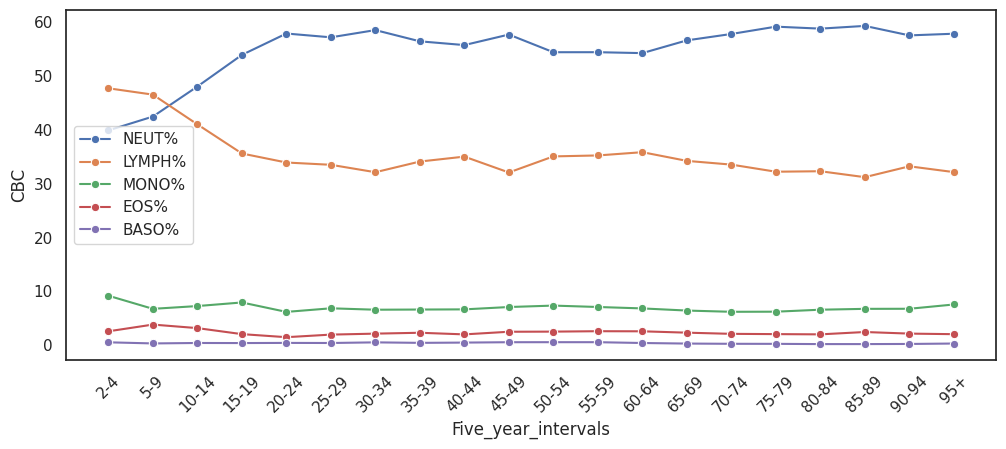

In [207]:
sns.set_style("white")
plt.rcParams["figure.figsize"] = (12, 10)

plt.subplot(2, 1, 1)
percent_cols = [
    "NEUT%_recalc",
    "LYMPH%_recalc",
    "MONO%_recalc",
    "EOS%_recalc",
    "BASO%_recalc",
]

for col in percent_cols:
    sns.lineplot(
        data=grouped_data,
        x="Five_year_intervals",
        y=col,
        marker="o",
        label=col.replace("%_recalc", "%"),
    )

plt.title("", fontsize=14)
plt.xlabel("Five_year_intervals", fontsize=12)
plt.ylabel("CBC", fontsize=12)
plt.xticks(rotation=45)
plt.legend()

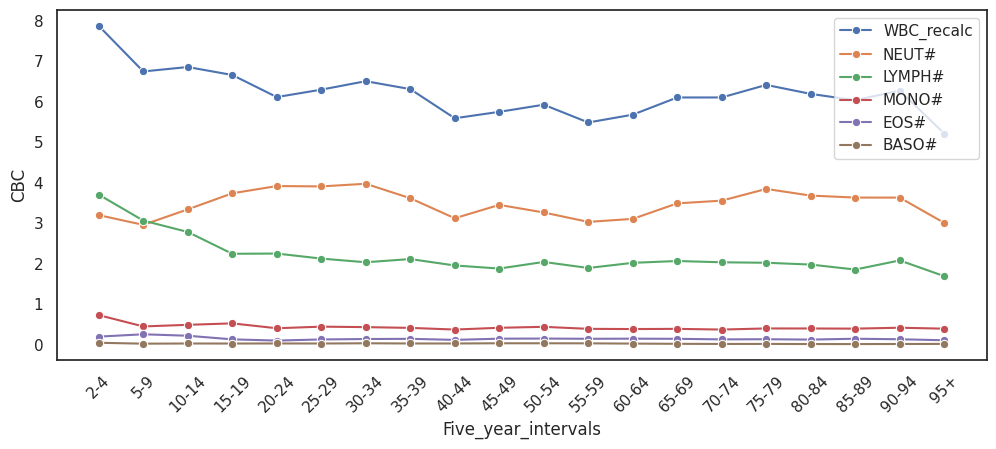

In [208]:
plt.subplot(2, 1, 2)
count_cols = ["WBC_recalc", "NEUT#", "LYMPH#", "MONO#", "EOS#", "BASO#"]

for col in count_cols:
    sns.lineplot(
        data=grouped_data,
        x="Five_year_intervals",
        y=col,
        marker="o",
        label=col.replace("%_recalc", "%"),
    )

plt.title("", fontsize=14)
plt.xlabel("Five_year_intervals", fontsize=12)
plt.ylabel("CBC", fontsize=12)
plt.xticks(rotation=45)
plt.legend()

# 计算五分类和细胞比例的关系; 无需CLR

In [96]:
groupby = "Classification_L2"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [97]:
Level_counts_frac.columns

Index(['ClinicalID', 'Donor_total_cell_counts', 'ClinicalID_PBMC_count',
       'ClinicalID_NDN_BAS_count', 'B cells#', 'CD4+ T cells#', 'DC#',
       'DN T cells#', 'Granulocytes#_x', 'HSPC#', 'ILCs#', 'MAIT#',
       'Monocytes#', 'NKT#', 'Non-MAIT/NKT CD8+ T cells#', 'γδ T cells#',
       'B cells%_in_PBMC', 'CD4+ T cells%_in_PBMC', 'DC%_in_PBMC',
       'DN T cells%_in_PBMC', 'Granulocytes%_in_PBMC', 'HSPC%_in_PBMC',
       'ILCs%_in_PBMC', 'MAIT%_in_PBMC', 'Monocytes%_in_PBMC', 'NKT%_in_PBMC',
       'Non-MAIT/NKT CD8+ T cells%_in_PBMC', 'γδ T cells%_in_PBMC',
       'Granulocytes#_y', 'Granulocytes%_in_NDN_BAS', 'DonorID', 'Batch',
       'Gender', 'Pregnancy', 'Pregnancy stage', 'Sampling time',
       'Age_in_Months', 'Age_in_Years', 'Ten_year_intervals',
       'Five_year_intervals', 'Simplified_intervals', 'WBC_recalc',
       'NEUT%_recalc', 'LYMPH%_recalc', 'MONO%_recalc', 'EOS%_recalc',
       'BASO%_recalc', 'NEUT#', 'LYMPH#', 'MONO#', 'EOS#', 'BASO#', 'RBC',
       'HGB'

In [98]:
sc_classification = pd.DataFrame(
    {
        "ClinicalID": Level_counts_frac["ClinicalID"],
        'Age':Level_counts_frac["Age_in_Years"],
        "LYMPH": Level_counts_frac[
            [
                'B cells%_in_PBMC',
                'CD4+ T cells%_in_PBMC',
                'DN T cells%_in_PBMC',
                'MAIT%_in_PBMC',
                'NKT%_in_PBMC',
                'Non-MAIT/NKT CD8+ T cells%_in_PBMC',
                'γδ T cells%_in_PBMC',
                'ILCs%_in_PBMC',
            ]
        ].sum(axis=1),
        
        "MONO": Level_counts_frac[
            [
                'DC%_in_PBMC',
                'Granulocytes%_in_PBMC',# LDNs and Mast cells
                'HSPC%_in_PBMC',
                'Monocytes%_in_PBMC',
            ]
        ].sum(axis=1),
        
        "LYMPH#": Level_counts_frac['LYMPH#'],
        
        "MONO#": Level_counts_frac['MONO#'],
    }
)

In [99]:
sc_classification["LYMPH%_recalc2"] = (
    sc_classification["LYMPH#"] / (sc_classification["LYMPH#"] + sc_classification["MONO#"]) * 100).round(2)
sc_classification["MONO%_recalc2"] = (
    sc_classification["MONO#"] / (sc_classification["LYMPH#"] + sc_classification["MONO#"]) * 100).round(2)

In [100]:
sc_classification = sc_classification.sort_values('Age')

In [101]:
sc_classification['LYMPH'].corr(sc_classification['LYMPH%_recalc2'], method="spearman")

np.float64(0.6276993268609231)

In [102]:
sc_classification['MONO'].corr(sc_classification['MONO%_recalc2'], method="spearman")

np.float64(0.6278507103418206)

In [103]:
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='pdf')
import matplotlib as mpl
import matplotlib.font_manager as fm
mpl.rcParams['pdf.fonttype'] = 42
fm.fontManager.addfont("fonts/arial.ttf")
mpl.rcParams['font.family'] = 'arial'
mpl.rcParams['lines.linewidth'] = 0.5

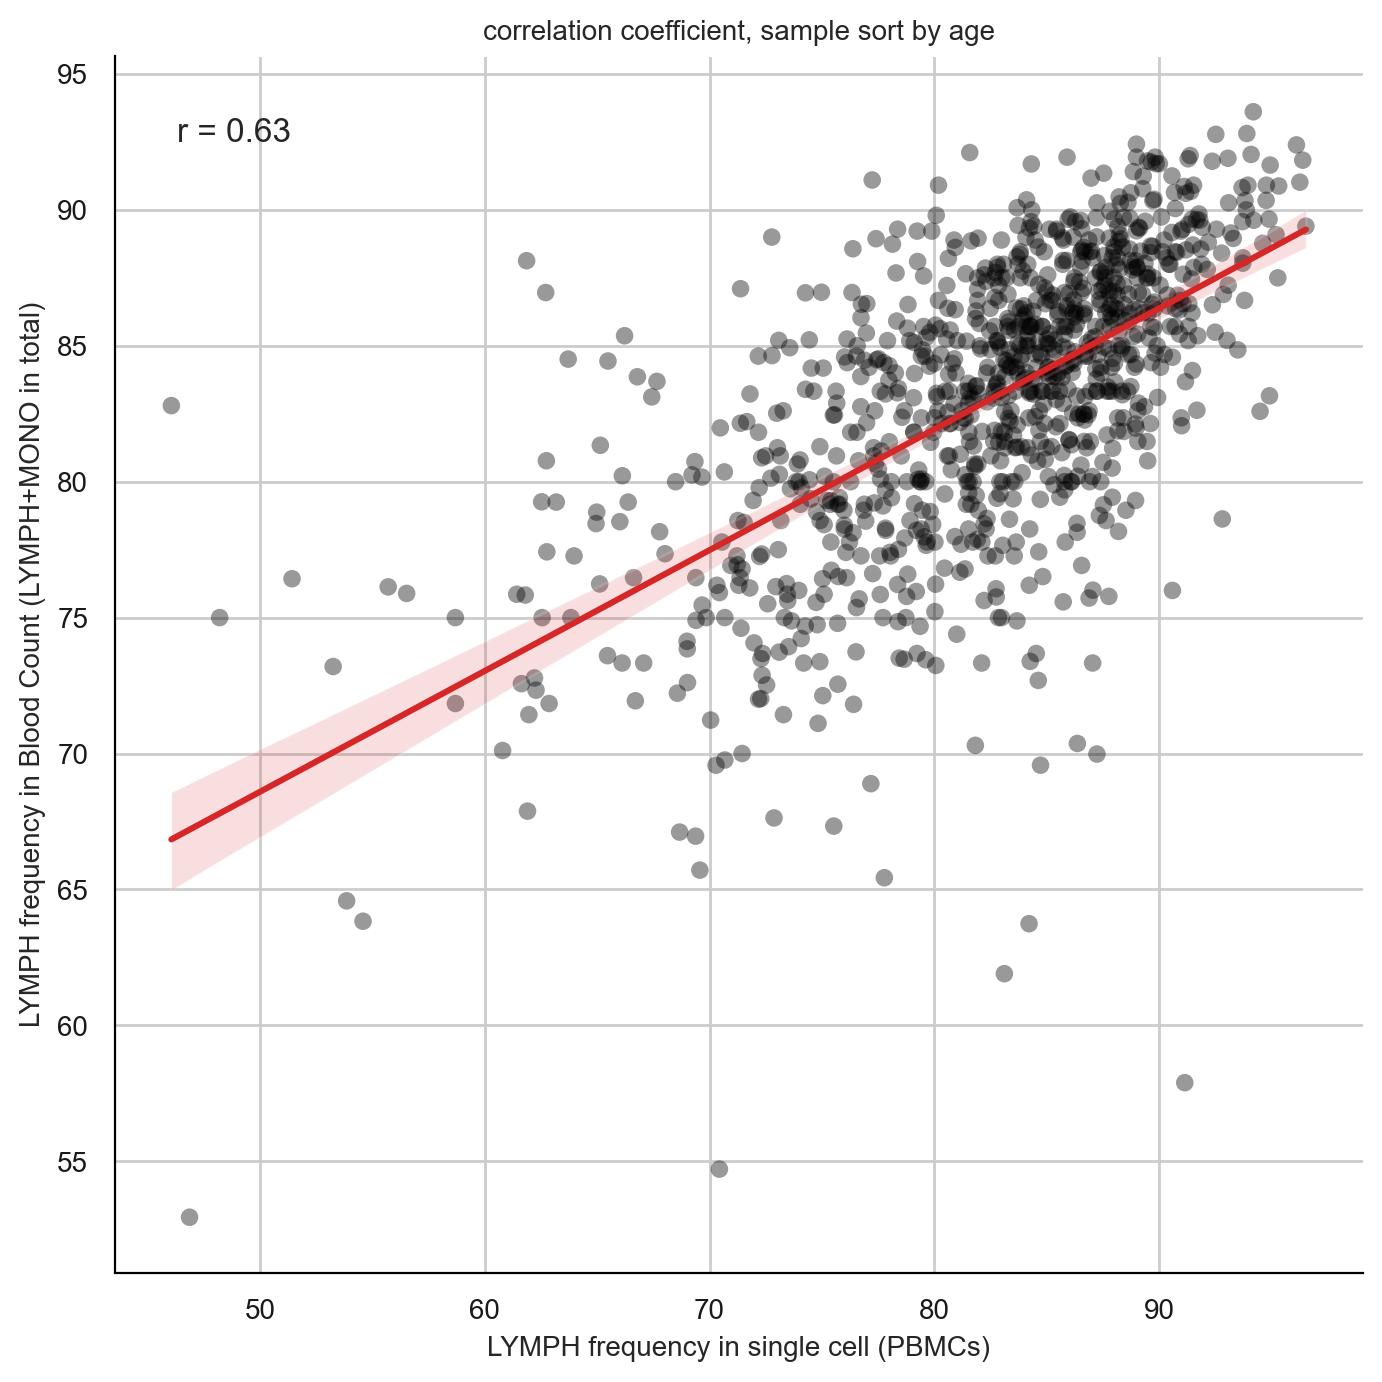

In [104]:
sns.regplot(
    data=sc_classification,
    x="LYMPH",
    y='LYMPH%_recalc2',
    scatter_kws={
        "color": "black",
        "alpha": 0.4,
        "s": 40,
        "edgecolor": "none"
    },
    line_kws={
        "color": "#D62728",
        "linewidth": 2.2
    }
)
plt.text(
    0.05, 0.95,
    f"r = 0.63",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.title(f"correlation coefficient, sample sort by age")
plt.xlabel("LYMPH frequency in single cell (PBMCs)")
plt.ylabel("LYMPH frequency in Blood Count (LYMPH+MONO in total)")
sns.despine()
plt.savefig('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/PBMC_blood_cor.pdf')
plt.show()

# 细胞比例的Ratio变化

In [83]:
groupby = "Classification_L4"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [84]:
pbmc_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()

In [85]:
pairs = itertools.combinations(pbmc_cols, 2)

In [86]:
for col1, col2 in pairs:
    cell1 = col1.replace("%_in_PBMC", "")
    cell2 = col2.replace("%_in_PBMC", "")
    new_col = f"{cell1}_vs_{cell2}_ratio"
    Level_counts_frac[new_col] = Level_counts_frac[col1] / Level_counts_frac[col2].replace(0, pd.NA)

In [87]:
ratio_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("_ratio")
].tolist()

In [88]:
data = Level_counts_frac[
    ['ClinicalID', 'Age_in_Years', 'Five_year_intervals'] + ratio_cols
]

In [89]:
corr_results = []
age = data['Age_in_Years']
for col in ratio_cols:
    col_data = data[col]
    corr = age.corr(col_data, method="spearman")

    corr_results.append(
        {
            "ratio_column": col,
            "age": 'Age_in_Years',
            "correlation": corr,
        }
    )

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [90]:
corr_df[abs(corr_df['correlation']) > 0.5].sort_values("correlation").to_csv('corr.csv')

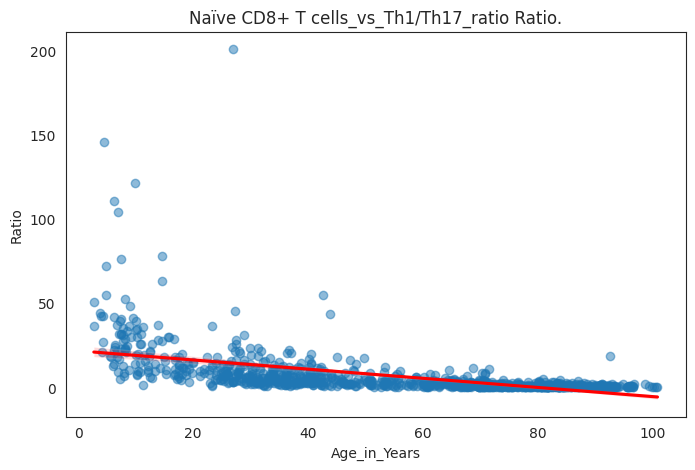

In [91]:
col = 'Naïve CD8+ T cells_vs_Th1/Th17_ratio'
plt.figure(figsize=(8, 5))

plot_data = pd.DataFrame({
    'Age_in_Years':pd.to_numeric(data['Age_in_Years']),
    col:pd.to_numeric(data[col]),
}).dropna().drop_duplicates()

sns.regplot(
    data=plot_data,
    x="Age_in_Years",
    y=col,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title(f"{col} Ratio.")
plt.xlabel("Age_in_Years")
plt.ylabel("Ratio")
plt.show()

In [92]:
grouped_data = data.groupby("Five_year_intervals", as_index=False).agg(
    {col: "mean" for col in ratio_cols}
)

grouped_data["Five_year_intervals"] = pd.Categorical(
    grouped_data["Five_year_intervals"],
    categories=[
        "2-4",
        "5-9",
        "10-14",
        "15-19",
        "20-24",
        "25-29",
        "30-34",
        "35-39",
        "40-44",
        "45-49",
        "50-54",
        "55-59",
        "60-64",
        "65-69",
        "70-74",
        "75-79",
        "80-84",
        "85-89",
        "90-94",
        "95+",
    ],
)

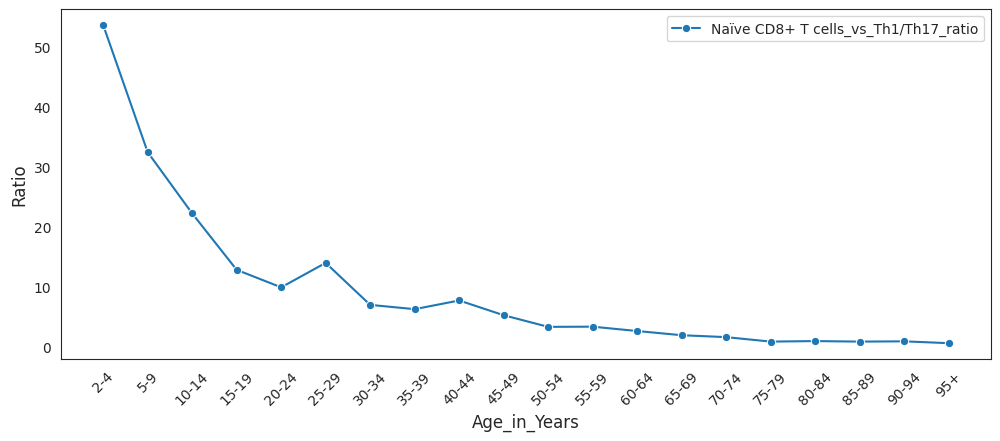

In [93]:
sns.set_style("white")
plt.rcParams["figure.figsize"] = (12, 10)

plt.subplot(2, 1, 1)
percent_cols = [col]

for col in percent_cols:
    sns.lineplot(
        data=grouped_data,
        x="Five_year_intervals",
        y=col,
        marker="o",
        label=col.replace("%_recalc", "%"),
    )

plt.title("", fontsize=14)
plt.xlabel("Age_in_Years", fontsize=12)
plt.ylabel("Ratio", fontsize=12)
plt.xticks(rotation=45)
plt.legend()

# PBMC和中性粒细胞间的相关性,需要CLR
#pbmc成分对中性粒组成性影响1

In [158]:
groupby = "Classification_L4"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [159]:
pbmc_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()
neu_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_NDN_BAS")
].tolist()

In [160]:
pbmc_data = Level_counts_frac[pbmc_cols]
neu_data = Level_counts_frac[neu_cols]

In [161]:
pbmc_data = clr(pbmc_data+1e-10)
neu_data = clr(neu_data+1e-10)

In [162]:
pbmc_data = pd.DataFrame(
    pbmc_data,
    index=Level_counts_frac.ClinicalID,  # 恢复行索引
    columns=pbmc_cols  # 恢复列名
)

In [163]:
neu_data = pd.DataFrame(
    neu_data,
    index=Level_counts_frac.ClinicalID,  # 恢复行索引
    columns=neu_cols  # 恢复列名
)

In [164]:
corr_results = []
for pbmc_col in pbmc_cols:
    for neu_col in neu_cols:
        # 提取两列数据
        pbmc_data_col = pbmc_data[pbmc_col]
        neu_data_col = neu_data[neu_col]

        corr = pbmc_data_col.corr(neu_data_col, method="pearson")

        corr_results.append(
            {"pbmc_column": pbmc_col, "neu_column": neu_col, "correlation": corr}
        )

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [165]:
corr_df.sort_values("correlation")

,pbmc_column,neu_column,correlation
479,Intermediate monocytes%_in_PBMC,VIM- FLNA- NDNs%_in_NDN_BAS,-0.188751
478,Intermediate monocytes%_in_PBMC,RGS2- NDNs%_in_NDN_BAS,-0.143602
472,Intermediate monocytes%_in_PBMC,CXCL8- PTGS2+ NDNs%_in_NDN_BAS,-0.143509
474,Intermediate monocytes%_in_PBMC,FOS- NDNs%_in_NDN_BAS,-0.141536
417,HSC/MPP%_in_PBMC,MT-ATP6- MT-CO2- NDNs%_in_NDN_BAS,-0.140738
...,...,...,...
845,cDC1%_in_PBMC,IFIT2- RNF213- NDNs%_in_NDN_BAS,0.146914
105,CD27+ MAIT%_in_PBMC,IFIT2- RNF213- NDNs%_in_NDN_BAS,0.149107
846,cDC1%_in_PBMC,IRF1- GBP2- NDNs%_in_NDN_BAS,0.176362
475,Intermediate monocytes%_in_PBMC,IFIT2- RNF213- NDNs%_in_NDN_BAS,0.214301


<Figure size 3000x3000 with 0 Axes>

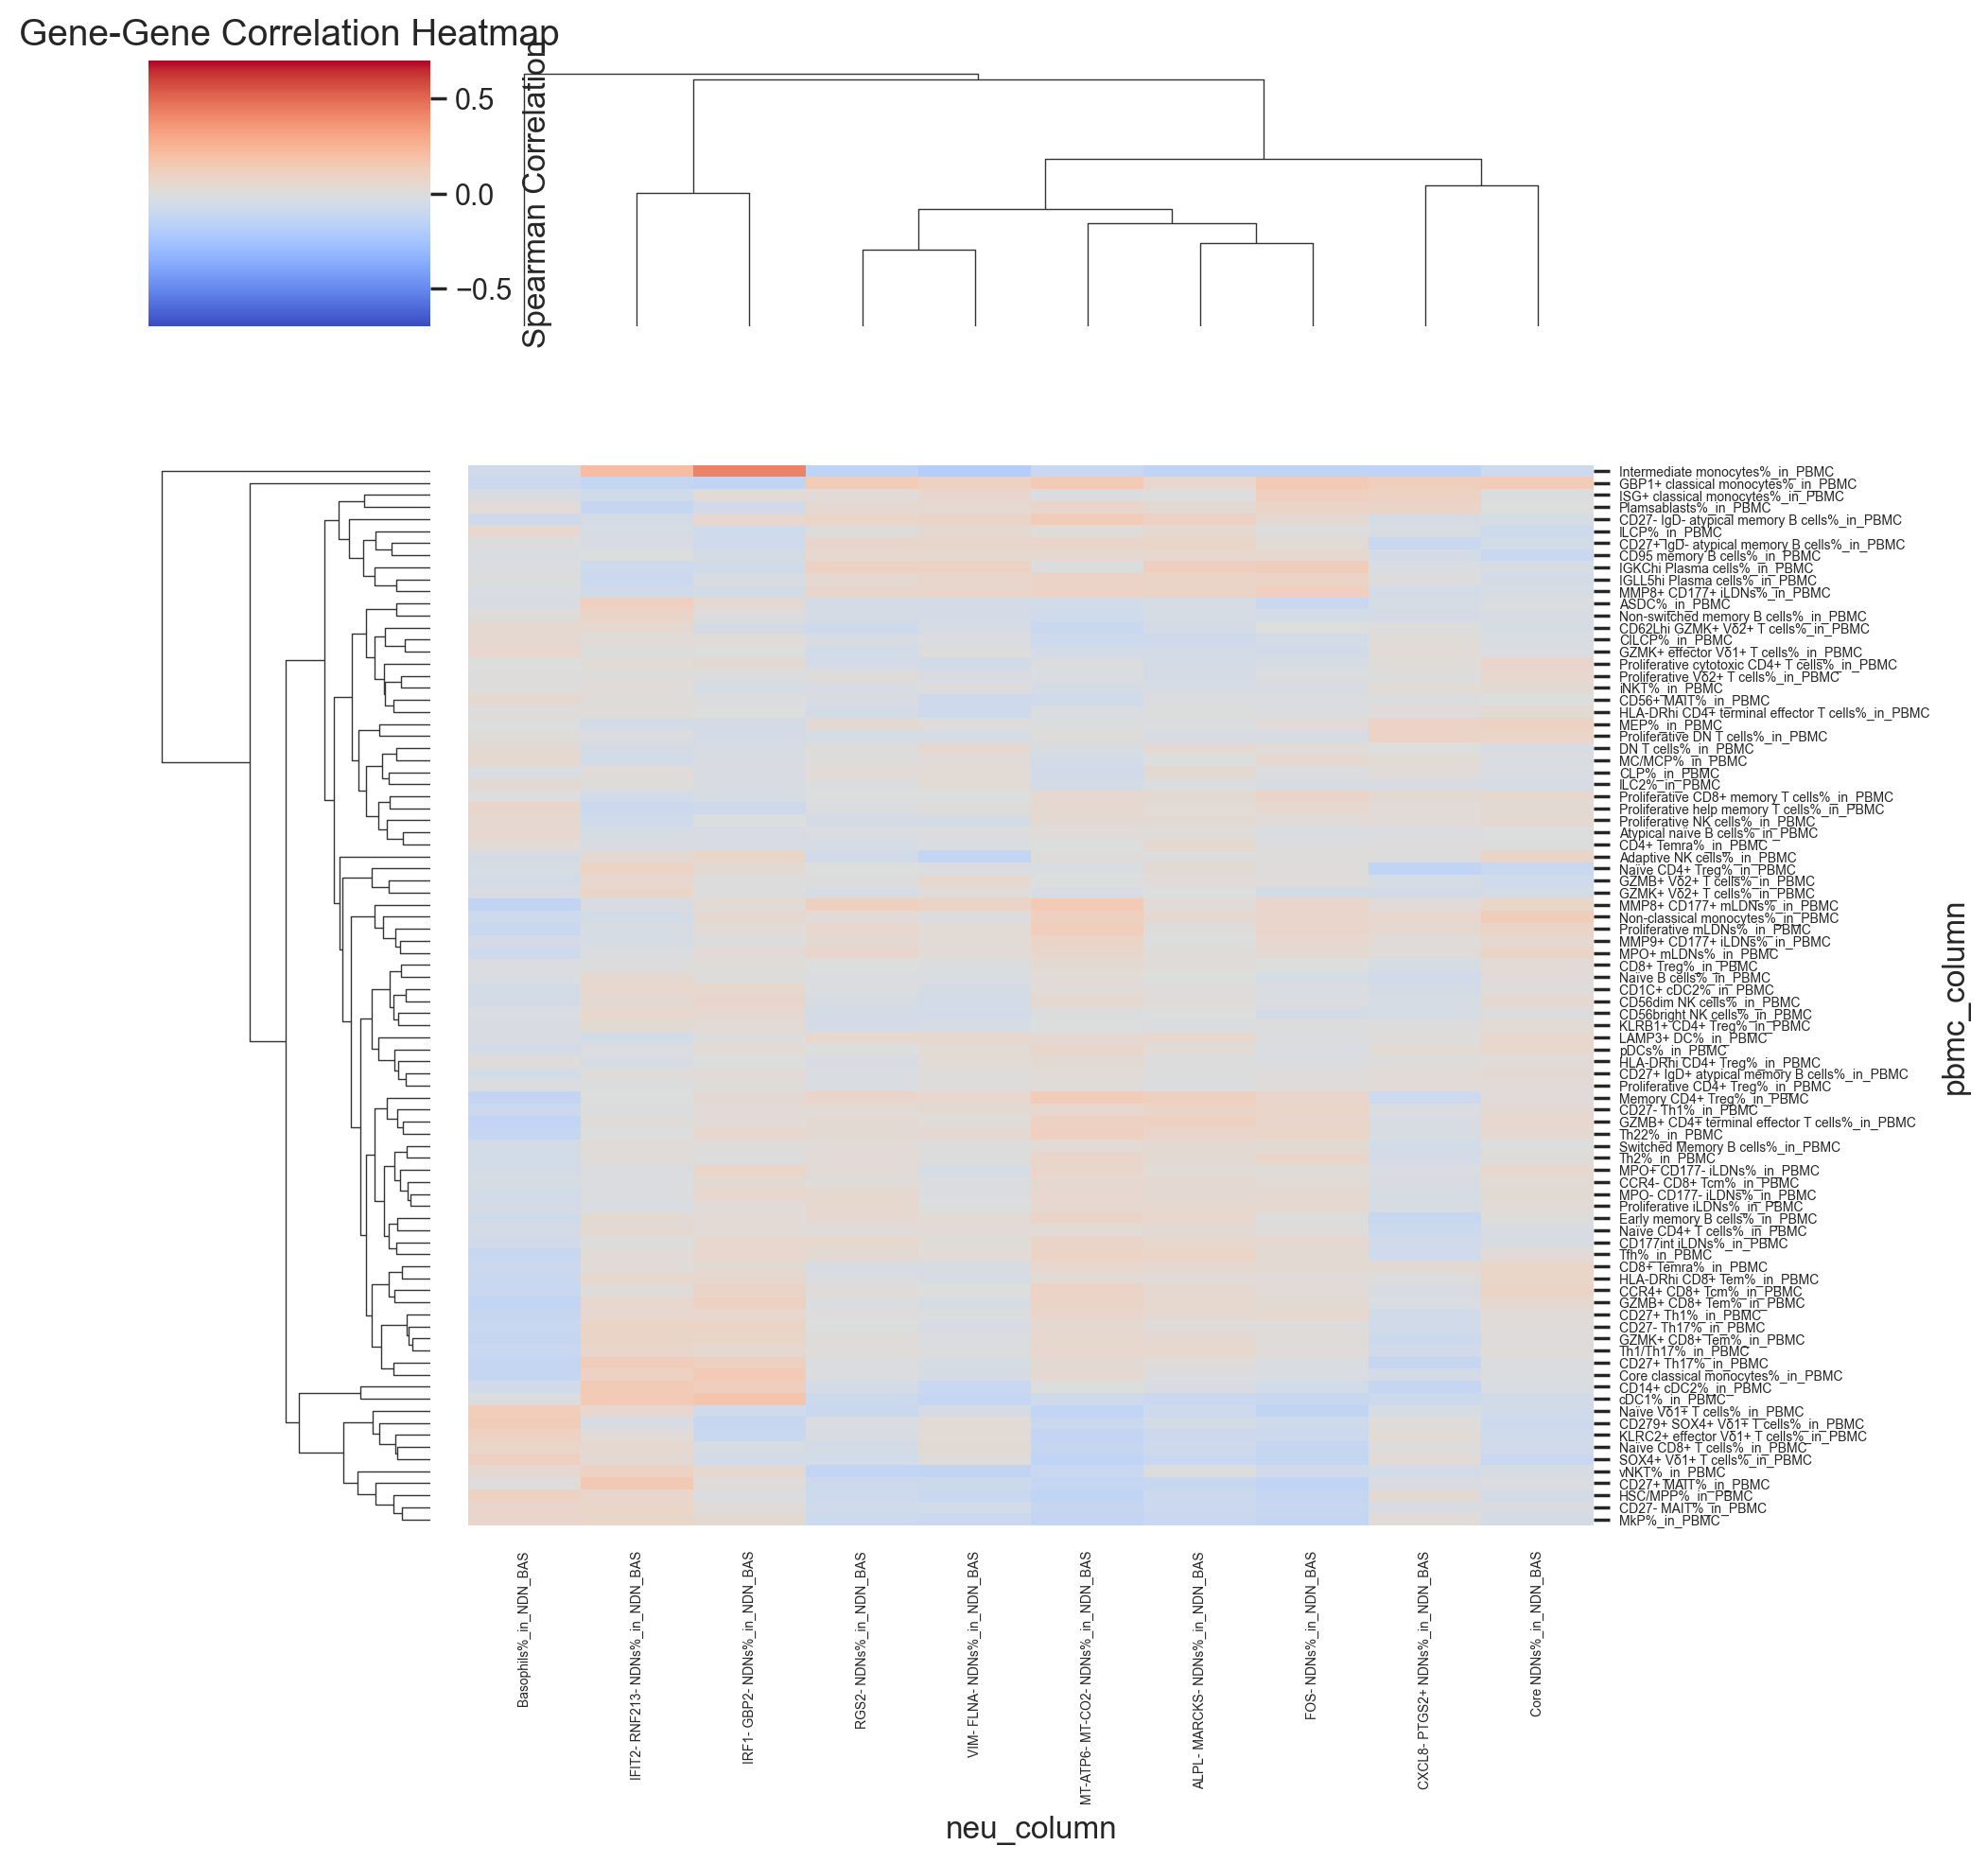

In [167]:
plt.figure(figsize=(30, 30))
sns.set(style="white")
g = sns.clustermap(
    corr_df,
    pivot_kws={
        "index": "pbmc_column",  # 行索引
        "columns": "neu_column",  # 列索引
        "values": "correlation",  # 单元格值
    },
    cmap="coolwarm",  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,  # 单元格为正方形
    vmin=-0.7,
    vmax=0.7,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,  # 单元格边框宽度
    cbar_kws={"label": "Spearman Correlation"},  # 颜色条标签
    row_cluster=True,  # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,  # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,  # 与Y轴一致
)
plt.title("Gene-Gene Correlation Heatmap", fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

# plt.savefig('gene_correlation_heatmap.png', dpi=300, bbox_inches='tight')  # 保存为高清图片
plt.show()

# PBMC细胞比例和临床的相关性

In [5]:
groupby = "Classification_L4"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [6]:
pbmc_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()
neu_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_NDN_BAS")
].tolist()
clinical_cols = [  # 临床
    "WBC_recalc",
    "NEUT%_recalc",
    "LYMPH%_recalc",
    "MONO%_recalc",
    "EOS%_recalc",
    "BASO%_recalc",
    "NEUT#",
    "LYMPH#",
    "MONO#",
    "EOS#",
    "BASO#",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC",
    "RDW-CV",
    "PLT",
    "PCT",
    "PDW",
    "MPV",
    "AST",
    "ALT",
    "AST:ALT",
    "GGT",
    "CEA",
    "AFP",
    "ALB",
    "GLB",
    "A:G",
    "TP",
    "TBIL",
    "DBIL",
    "IBIL",
    "ALP",
    "TC",
    "TG",
    "HDL-C",
    "LDL-C",
    "Cr",
    "UREA",
    "UA",
    "BMI",
    "Glucose",
]

In [7]:
corr_results = []
for celltype_col in pbmc_cols + neu_cols:
    for clinical_col in clinical_cols:
        # 提取两列数据
        celltype_data = Level_counts_frac[celltype_col]
        clinical_data = Level_counts_frac[clinical_col]

        corr = celltype_data.corr(clinical_data, method="spearman")

        corr_results.append(
            {
                "celltype_column": celltype_col,
                "clinical_column": clinical_col,
                "correlation": corr,
            }
        )

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [8]:
corr_df.sort_values("correlation")

,celltype_column,clinical_column,correlation
1397,GBP1+ classical monocytes%_in_PBMC,LYMPH%_recalc,-0.541985
2432,MMP8+ CD177+ mLDNs%_in_PBMC,LYMPH%_recalc,-0.511985
1262,Core classical monocytes%_in_PBMC,LYMPH%_recalc,-0.455033
2906,Naïve CD8+ T cells%_in_PBMC,CEA,-0.432638
2909,Naïve CD8+ T cells%_in_PBMC,GLB,-0.429780
...,...,...,...
2566,MPO+ mLDNs%_in_PBMC,NEUT%_recalc,0.404408
2436,MMP8+ CD177+ mLDNs%_in_PBMC,NEUT#,0.406008
2910,Naïve CD8+ T cells%_in_PBMC,A:G,0.414973
1396,GBP1+ classical monocytes%_in_PBMC,NEUT%_recalc,0.469995


<Figure size 3000x3000 with 0 Axes>

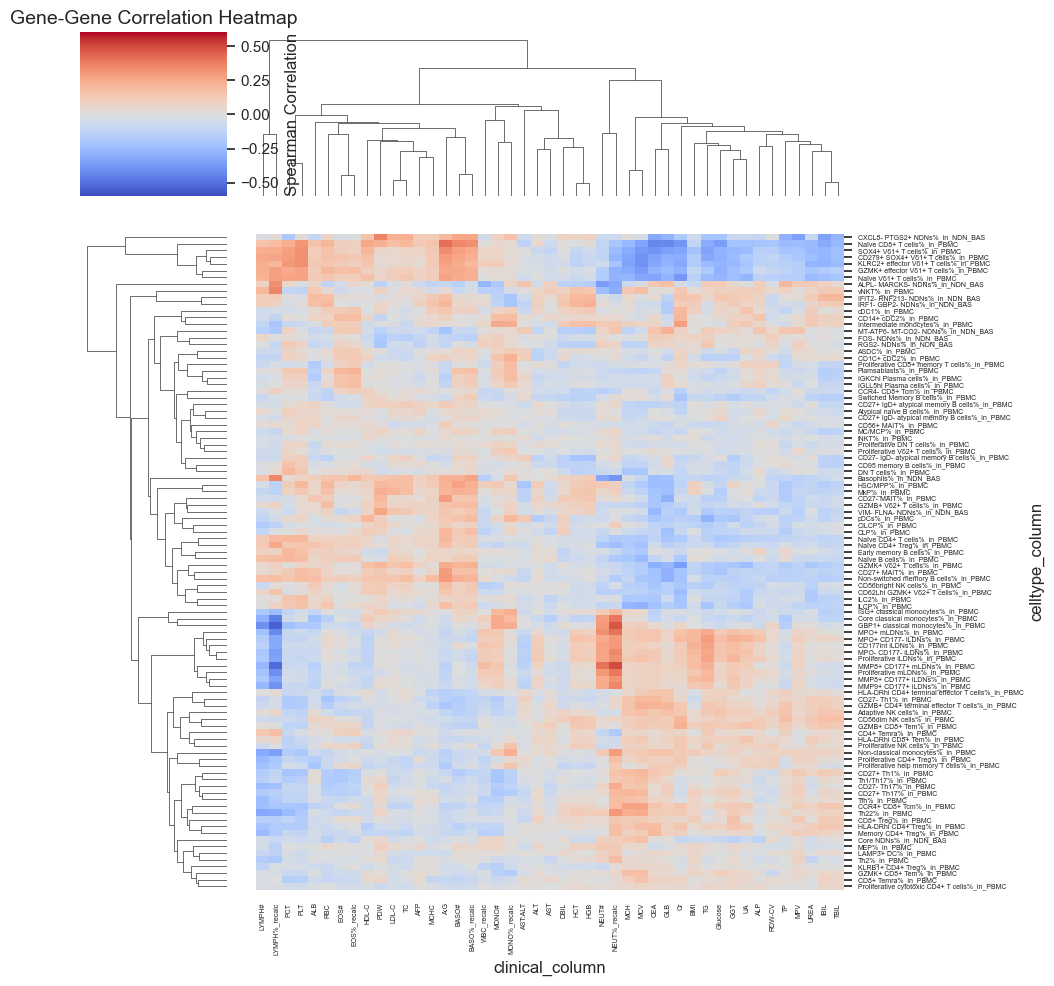

In [13]:
plt.figure(figsize=(30, 30))
sns.set(style="white")
g = sns.clustermap(
    corr_df,
    pivot_kws={
        "index": "celltype_column",  # 行索引
        "columns": "clinical_column",  # 列索引
        "values": "correlation",  # 单元格值
    },
    cmap="coolwarm",  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,  # 单元格为正方形
    vmin=-0.6,
    vmax=0.6,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,  # 单元格边框宽度
    cbar_kws={"label": "Spearman Correlation"},  # 颜色条标签
    row_cluster=True,  # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,  # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,  # 与Y轴一致
)
plt.title("Gene-Gene Correlation Heatmap", fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

plt.savefig('/home/liyanguo/MyImmuCell/08_supp_outputs/gene_correlation_heatmap.pdf', bbox_inches='tight')  # 保存为高清图片
plt.show()

# L3 PBMC和PBMC细胞间的相关性 

In [105]:
groupby = "Classification_L4"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [106]:
pbmc_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()

In [107]:
Level_counts_frac = Level_counts_frac[pbmc_cols]

In [109]:
clr_matrix = clr(Level_counts_frac + 1e-10)

In [110]:
clr_matrix = pd.DataFrame(
    clr_matrix,
    index=Level_counts_frac.index,  # 恢复行索引
    columns=Level_counts_frac.columns  # 恢复列名
)

In [111]:
corr_matrix = clr_matrix.corr(method="pearson")

In [117]:
corr_long = corr_matrix.stack().reset_index()
corr_long.columns = ["cell_type_1", "cell_type_2", "correlation"]
corr_long = corr_long[corr_long["cell_type_1"] < corr_long["cell_type_2"]]

In [119]:
corr_long.max()

cell_type_1    pDCs%_in_PBMC
cell_type_2    vNKT%_in_PBMC
correlation         0.945737
dtype: object

<Figure size 3000x3000 with 0 Axes>

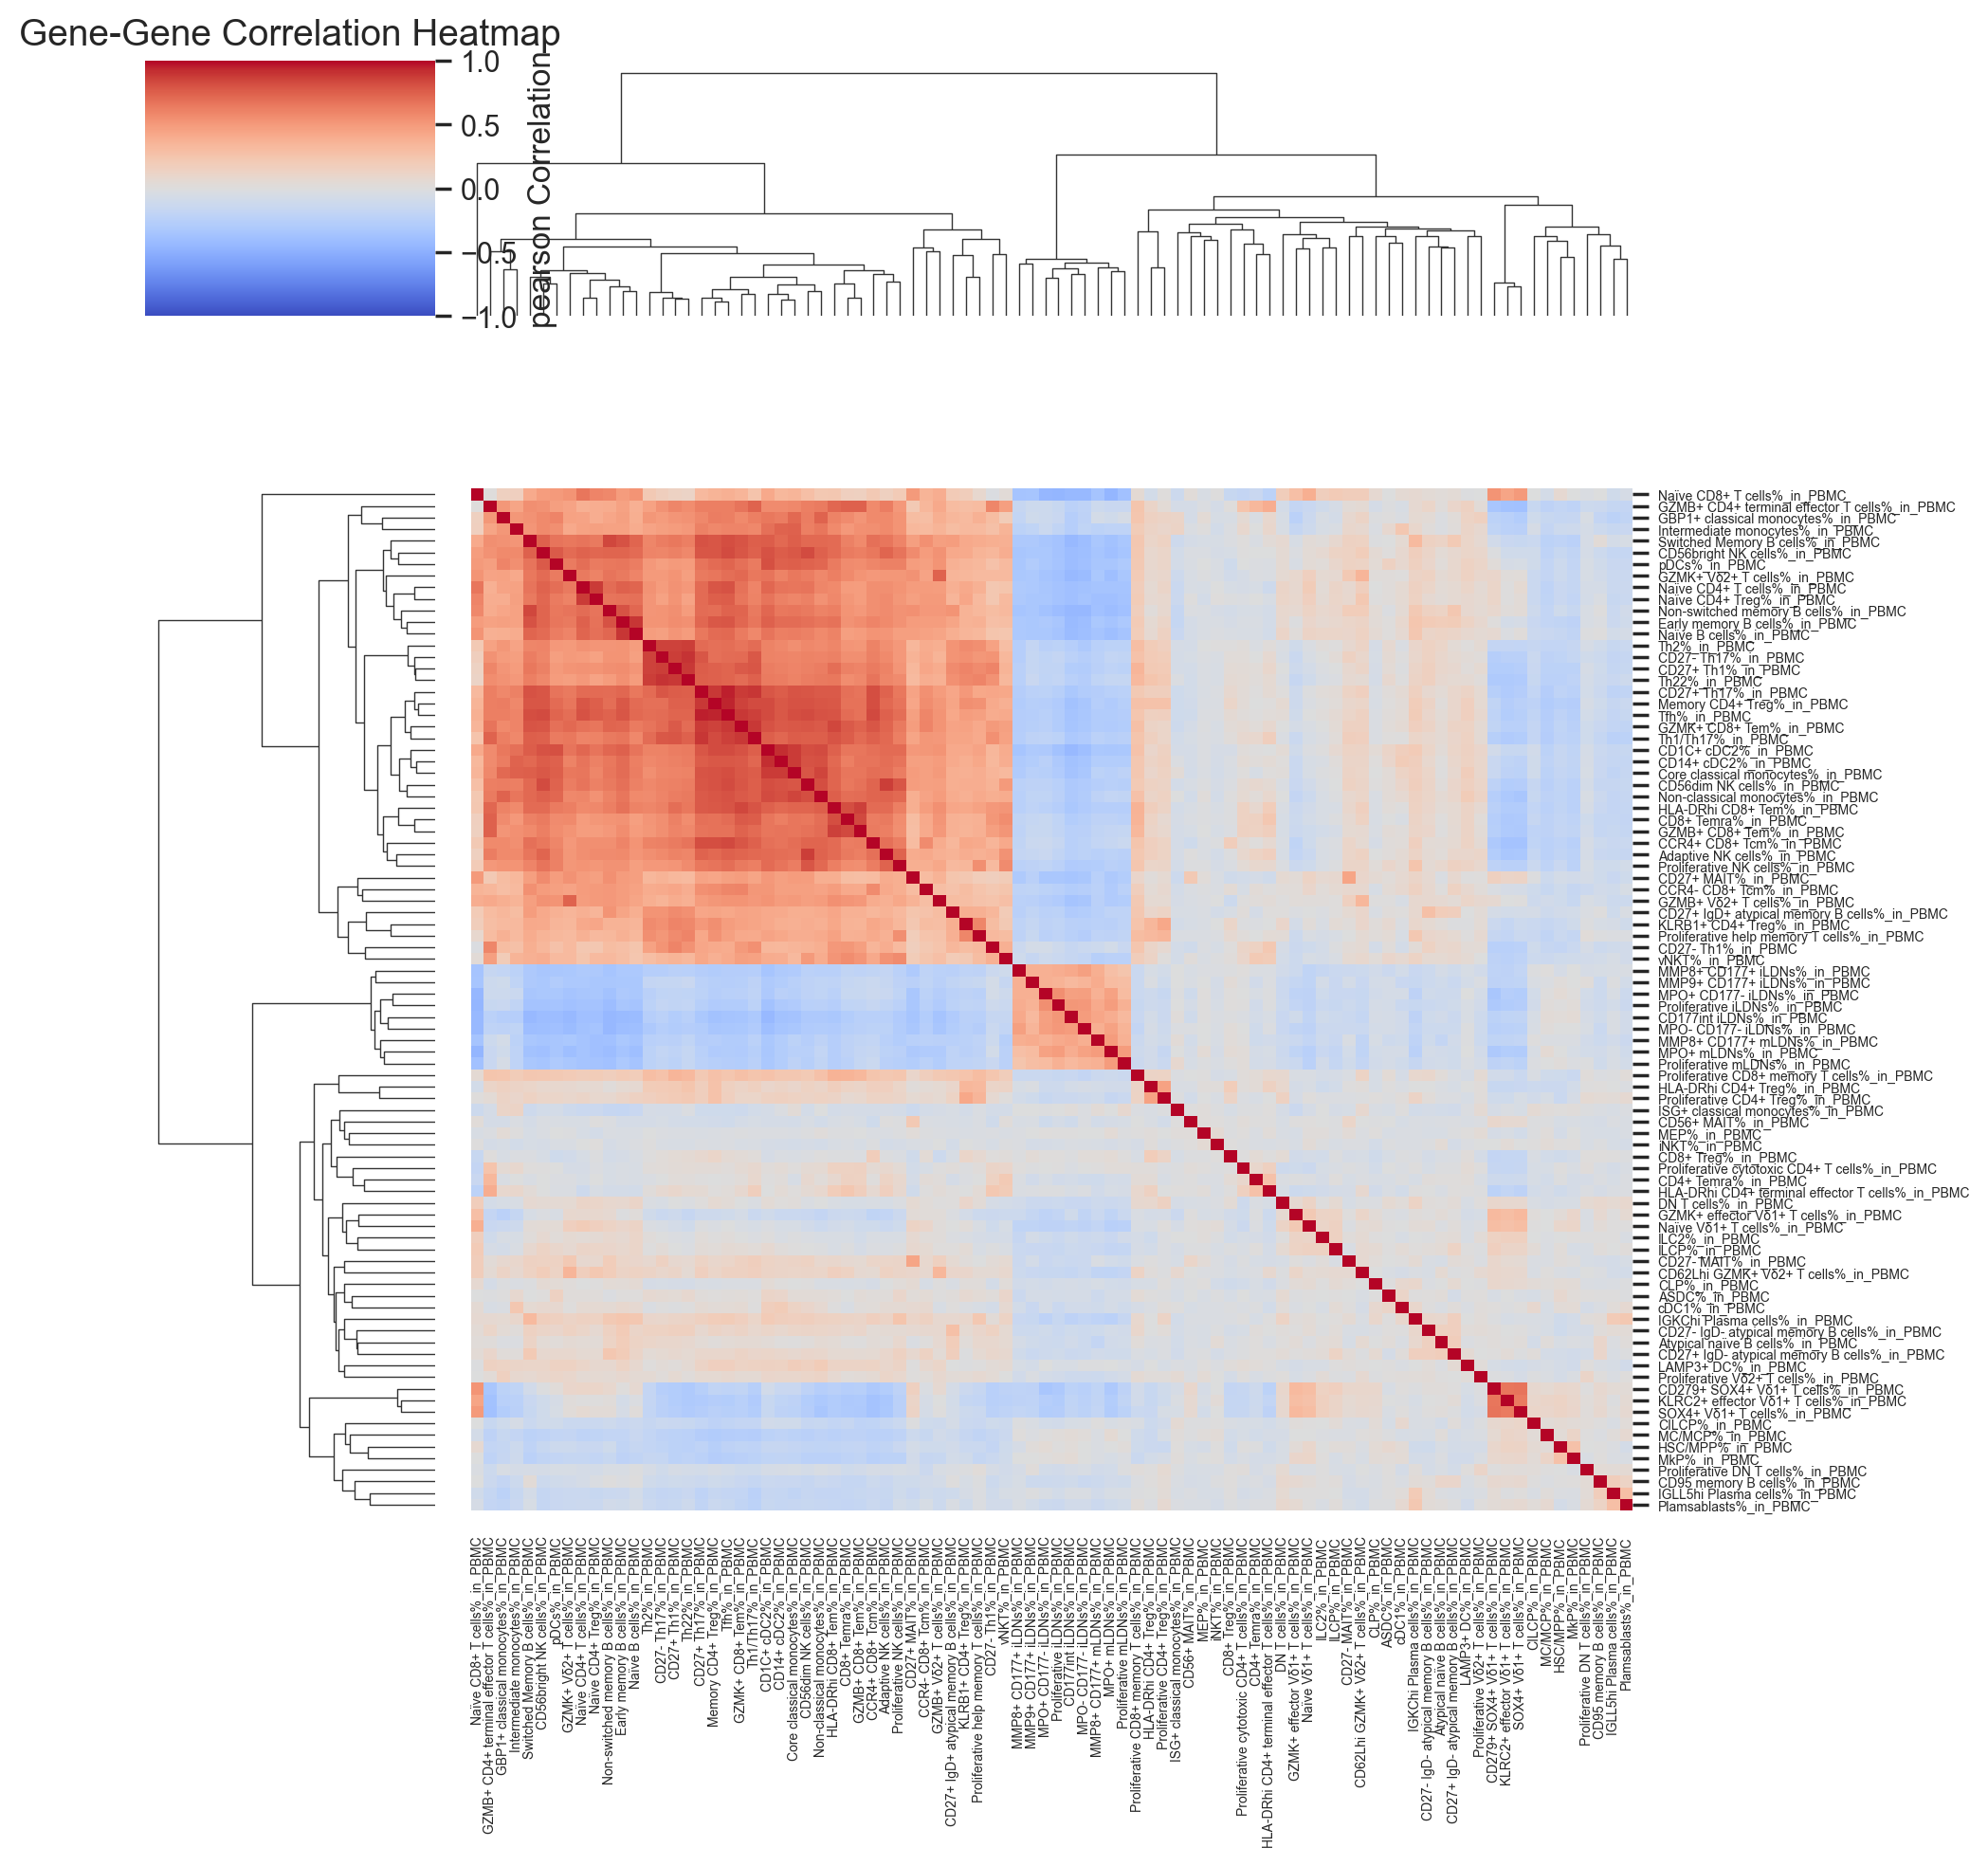

In [113]:
plt.figure(figsize=(30, 30))
sns.set(style="white")
g = sns.clustermap(
    corr_matrix,
    cmap="coolwarm",  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    # square=True,      # 单元格为正方形
    vmin=-1,
    vmax=1,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,  # 单元格边框宽度
    cbar_kws={"label": "pearson Correlation"},  # 颜色条标签
    row_cluster=True,  # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,  # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,  # 与Y轴一致
)
plt.title("Gene-Gene Correlation Heatmap", fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

plt.savefig('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/L4_PBMC_correlation_heatmap.pdf')  # 保存为高清图片
plt.show()

# CD4 CD8比例

In [197]:
groupby = "Classification_L2"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [198]:
Level_counts_frac["CD4_CD8_T_ratio"] = (
    Level_counts_frac["CD4+ T cells%_in_PBMC"] + Level_counts_frac["MAIT%_in_PBMC"]
) / Level_counts_frac["Non-MAIT/NKT CD8+ T cells%_in_PBMC"]

In [201]:
Level_counts_frac["CD4_CD8_T_ratio"].describe()

count    994.000000
mean       1.635622
std        1.090361
min        0.225839
25%        1.003834
50%        1.436253
75%        1.943478
max       16.073718
Name: CD4_CD8_T_ratio, dtype: float64

In [199]:
order_dict = {
    "Ten_year_intervals": [
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ]
}

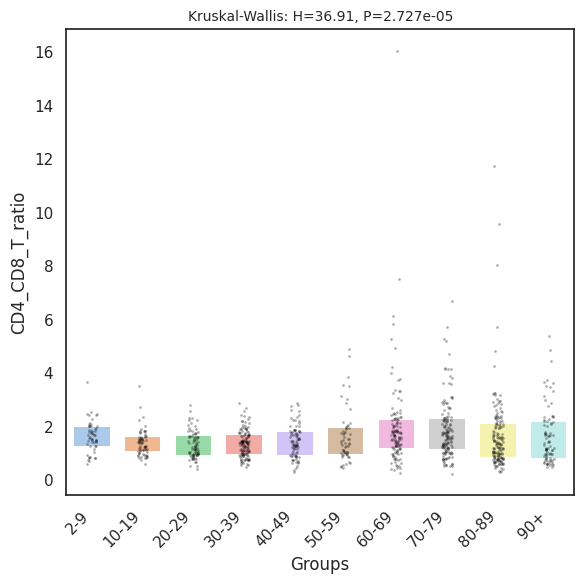

In [200]:
fig, ax = plt.subplots(figsize=(6, 6))
pastel_palette = sns.color_palette("pastel", n_colors=12)
sns.boxplot(
    x="Ten_year_intervals",
    y="CD4_CD8_T_ratio",
    data=Level_counts_frac,
    palette=pastel_palette,
    width=0.7,
    linewidth=0,
    showfliers=False,
    ax=ax,
    order=order_dict["Ten_year_intervals"],
)
sns.stripplot(
    x="Ten_year_intervals",
    y="CD4_CD8_T_ratio",
    data=Level_counts_frac,
    color="black",
    alpha=0.3,
    jitter=0.1,
    size=2,
    ax=ax,
    order=order_dict["Ten_year_intervals"],
)
ax.set_title(
    quick_stat_test(Level_counts_frac, "Ten_year_intervals", "CD4_CD8_T_ratio"),
    fontsize=10,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Groups", fontsize=12)
ax.set_ylabel("CD4_CD8_T_ratio", fontsize=12)
plt.tight_layout()

# Inflammation_index和细胞比例相关性

In [272]:
groupby = "Classification_L3"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [273]:
Inflammation_index = pd.DataFrame(
    {
        "ClinicalID": Level_counts_frac["ClinicalID"],
        "NLR_index": Level_counts_frac["NEUT#"]
        / Level_counts_frac["LYMPH#"],  # 中性粒细胞与淋巴细胞比值（NLR）
        "PLR_index": Level_counts_frac["PLT"]
        / Level_counts_frac["LYMPH#"],  # 血小板淋巴细胞比值 (PLR)
        "LMR_index": Level_counts_frac["LYMPH#"]
        / Level_counts_frac["MONO#"],  # 淋巴细胞/单核细胞比值（LMR)
        "NPR_index": Level_counts_frac["NEUT#"]
        / Level_counts_frac["PLT"],  # 中性粒细胞/血小板比值（NPR)
        "SIRI_index": Level_counts_frac["MONO#"]
        * Level_counts_frac["NEUT#"]
        / Level_counts_frac["LYMPH#"],  # 系统炎症反应指数/全身炎症反应指数（SIRI）
        "SII_index": Level_counts_frac["PLT"]
        * Level_counts_frac["NEUT#"]
        / Level_counts_frac[
            "LYMPH#"
        ],  # 全身免疫炎症指数(systemic immune-inflammation index，SII)
        "AISI_index": Level_counts_frac["MONO#"]
        * Level_counts_frac["NEUT#"]
        * Level_counts_frac["PLT"]
        / Level_counts_frac[
            "LYMPH#"
        ],  # 全身性炎症聚合指数（aggregate index of systemic inflammation， AISI） 等于泛免疫炎症值pan-immune-inflammation value（PIV）
    }
)

In [274]:
Level_counts_frac = pd.merge(Level_counts_frac, Inflammation_index, on="ClinicalID")

In [275]:
Level_counts_frac["Ten_year_intervals"] = pd.Categorical(
    Level_counts_frac["Ten_year_intervals"],
    categories=[
        "2-9",
        "10-19",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90+",
    ],
)

In [276]:
Inflammation_cols = [
    "NLR_index",
    "PLR_index",
    "LMR_index",
    "NPR_index",
    "SIRI_index",
    "SII_index",
    "AISI_index",
]

In [ ]:
# 统计检验
def quick_stat_test(data, plt_x, plt_y):
    groups = data[plt_x].dropna().unique()
    stats_data = [data[data[plt_x] == g][plt_y] for g in groups]
    if len(groups) == 2:
        t_stat, p_val = stats.ttest_ind(*stats_data, equal_var=False)
        return f"T-test: t={t_stat:.2f}, P={p_val:.4g}"
    elif len(groups) > 2:
        if data[plt_y].nunique() != 1:
            h_stat, p_val = stats.kruskal(*stats_data)
            return f"Kruskal-Wallis: H={h_stat:.2f}, P={p_val:.4g}"
    else:
        return "NA"

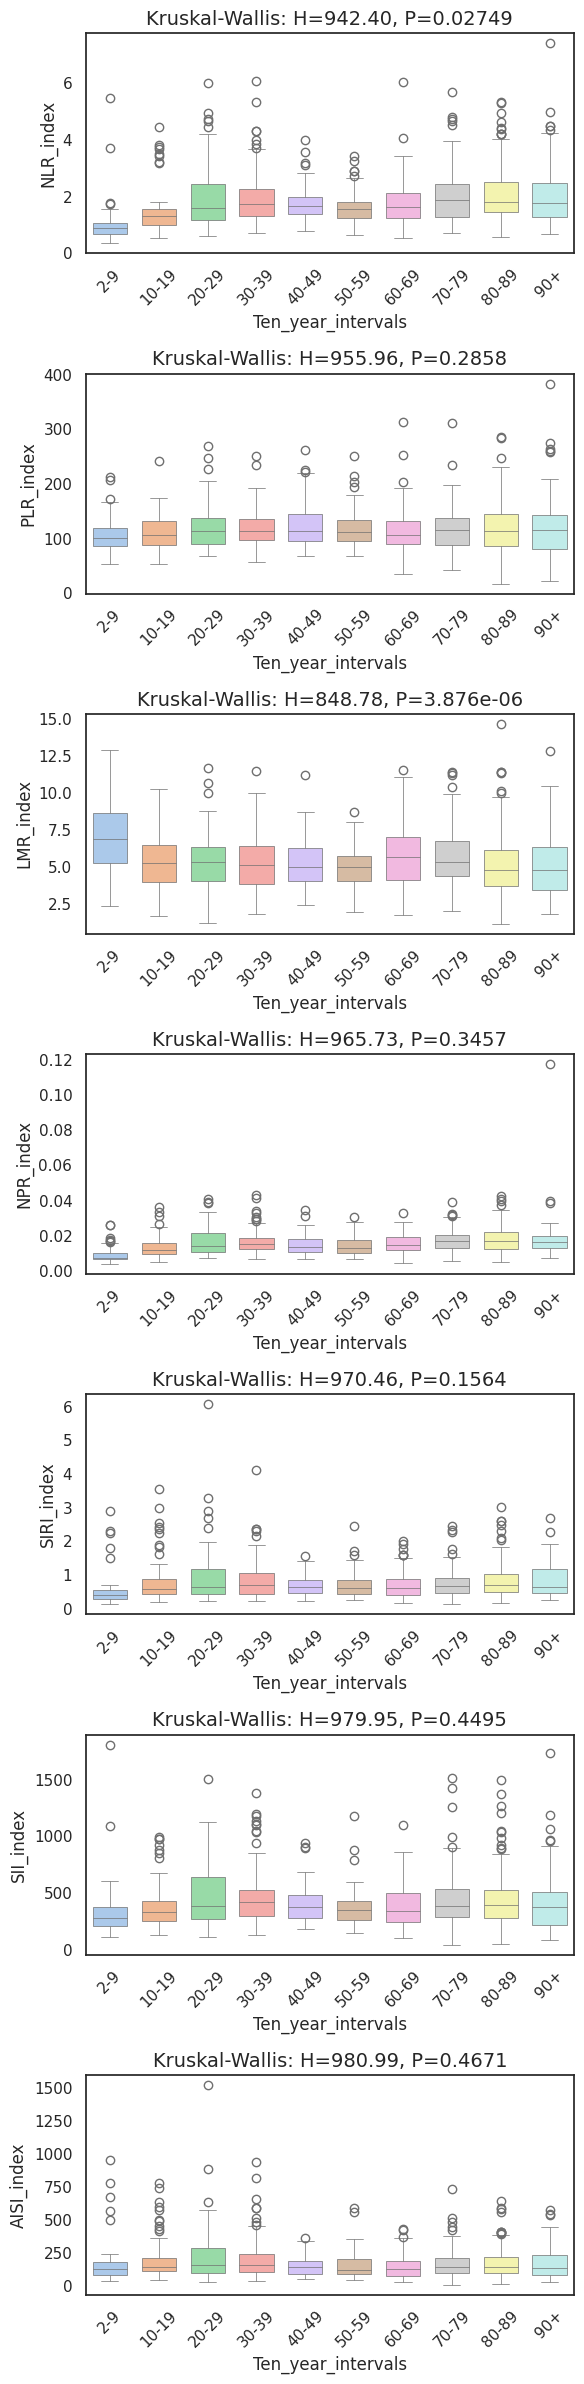

In [256]:
sns.set_style("white")
plt.figure(figsize=(6, 24))

n = len(Inflammation_cols)

for i, col in enumerate(Inflammation_cols, 1):
    plt.subplot(n, 1, i) 
    sns.boxplot(
        data=Level_counts_frac,
        x="Ten_year_intervals",
        y=col,
        palette="pastel",
        width=0.7,
        linewidth=0.5
    )
    plt.title(quick_stat_test(Level_counts_frac, col, "Ten_year_intervals"), fontsize=14)
    plt.xlabel("Ten_year_intervals", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

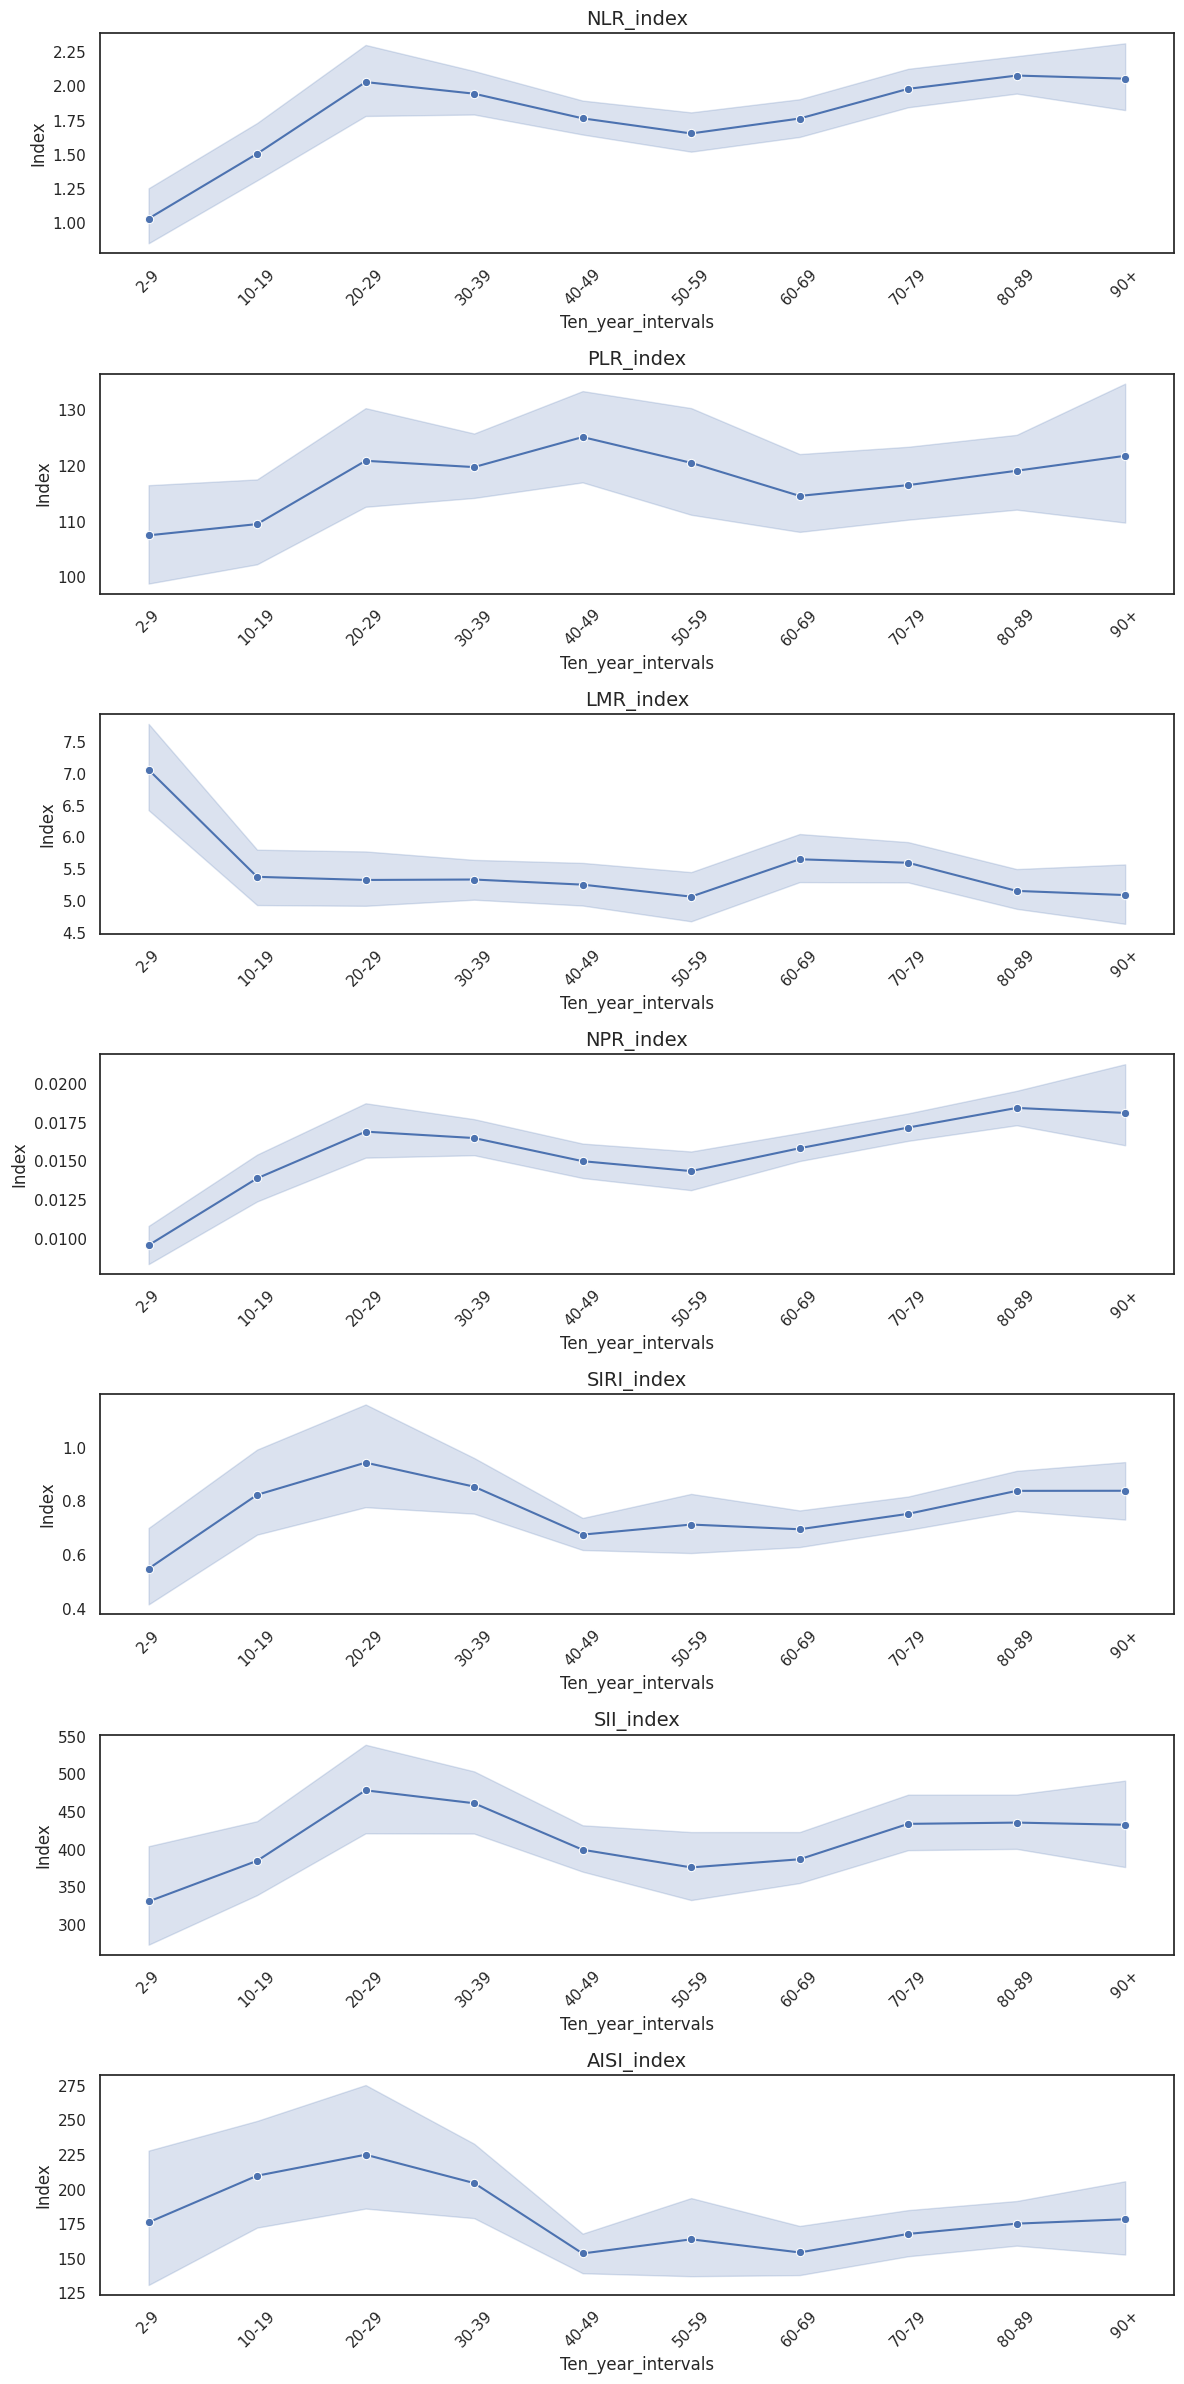

In [244]:
sns.set_style("white")
plt.figure(figsize=(12, 24))

n = len(Inflammation_cols)

for i, col in enumerate(Inflammation_cols, 1):
    plt.subplot(n, 1, i) 
    sns.lineplot(
        data=Level_counts_frac,
        x="Ten_year_intervals",
        y=col,
        marker="o"
    )
    plt.title(col, fontsize=14)
    plt.xlabel("Ten_year_intervals", fontsize=12)
    plt.ylabel("Index", fontsize=12)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [277]:
neu_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_NDN_BAS")
].tolist()
pbmc_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()

In [278]:
corr_results = []
for celltype_col in pbmc_cols + neu_cols:
    for Inflammation_col in Inflammation_cols:
        # 提取两列数据
        celltype_data = Level_counts_frac[celltype_col]
        Inflammation_data = Level_counts_frac[Inflammation_col]

        corr = celltype_data.corr(Inflammation_data, method="spearman")

        corr_results.append(
            {
                "celltype_column": celltype_col,
                "Inflammation_column": Inflammation_col,
                "correlation": corr,
            }
        )

# 转换为DataFrame便于查看和后续分析
corr_df = pd.DataFrame(corr_results)

In [279]:
corr_df.sort_values("correlation")

,celltype_column,Inflammation_column,correlation
44,Classical monocytes%_in_PBMC,LMR_index,-0.580336
163,Non-classical Monocytes%_in_PBMC,LMR_index,-0.411141
132,NKT%_in_PBMC,AISI_index,-0.369043
210,Basophils%_in_NDN_BAS,NLR_index,-0.367788
131,NKT%_in_PBMC,SII_index,-0.360056
...,...,...,...
91,LDNs%_in_PBMC,NLR_index,0.440599
47,Classical monocytes%_in_PBMC,SII_index,0.461436
48,Classical monocytes%_in_PBMC,AISI_index,0.514593
42,Classical monocytes%_in_PBMC,NLR_index,0.515047


<Figure size 3000x3000 with 0 Axes>

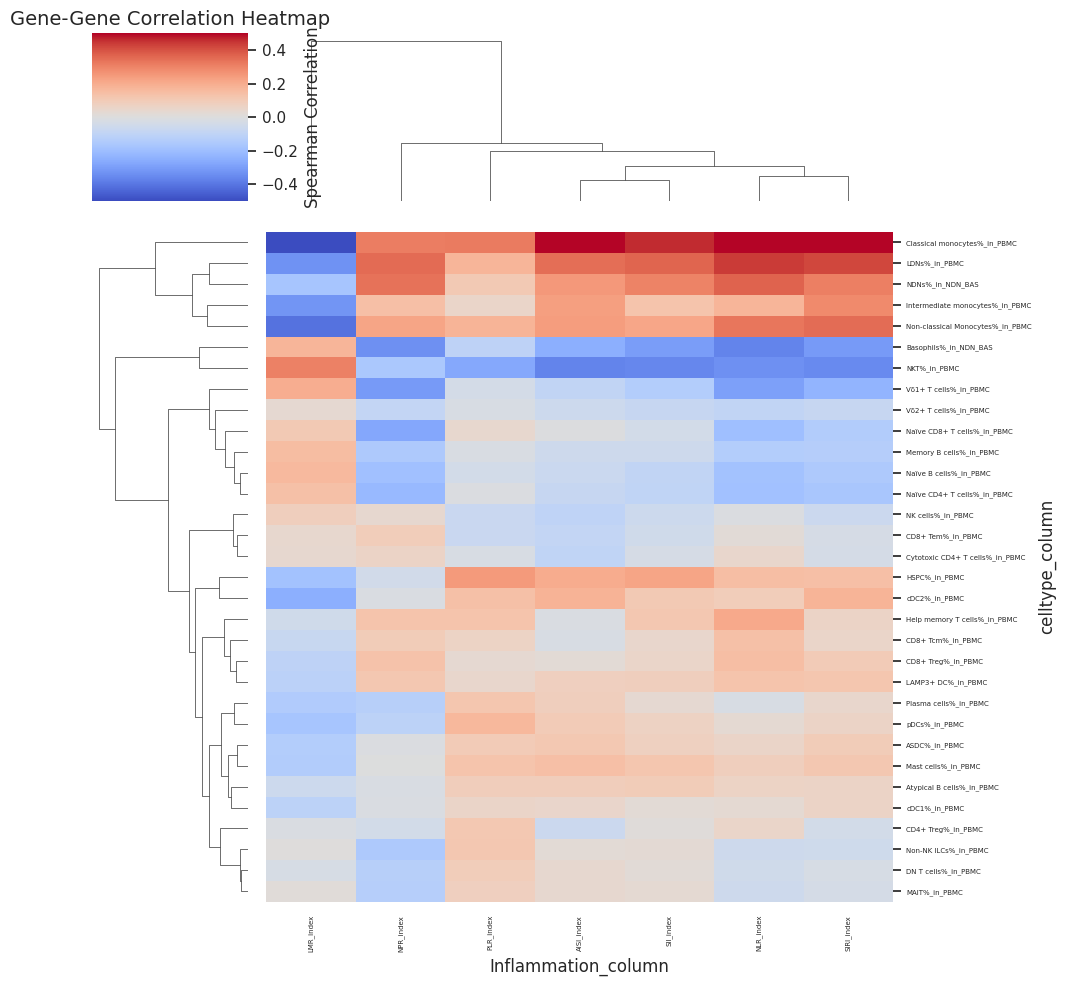

In [280]:
plt.figure(figsize=(30, 30))
sns.set(style="white")
g = sns.clustermap(
    corr_df,
    pivot_kws={
        "index": "celltype_column",  # 行索引
        "columns": "Inflammation_column",  # 列索引
        "values": "correlation",  # 单元格值
    },
    cmap="coolwarm",  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,  # 单元格为正方形
    vmin=-0.5,
    vmax=0.5,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,  # 单元格边框宽度
    cbar_kws={"label": "Spearman Correlation"},  # 颜色条标签
    row_cluster=True,  # 对行（基因）进行聚类
    col_cluster=True,  # 对列（基因）进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,  # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,  # 与Y轴一致
)
plt.title("Gene-Gene Correlation Heatmap", fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

# plt.savefig('gene_correlation_heatmap.png', dpi=300, bbox_inches='tight')  # 保存为高清图片
plt.show()

# 基于PBMC的聚类

In [257]:
groupby = "Classification_L3"
Level_counts_frac = pd.read_excel(f"{obj_path}{groupby}_donor_counts_frac_clinicl_table.xlsx", index_col=0)

In [258]:
pbmc_cols = Level_counts_frac.columns[
    Level_counts_frac.columns.str.contains("%_in_PBMC")
].tolist()

In [259]:
Level_counts_frac = Level_counts_frac[pbmc_cols]

In [260]:
Level_counts_frac

,ASDC%_in_PBMC,Atypical B cells%_in_PBMC,CD4+ Treg%_in_PBMC,CD8+ Tcm%_in_PBMC,CD8+ Tem%_in_PBMC,CD8+ Treg%_in_PBMC,Classical monocytes%_in_PBMC,Cytotoxic CD4+ T cells%_in_PBMC,DN T cells%_in_PBMC,HSPC%_in_PBMC,Help memory T cells%_in_PBMC,Intermediate monocytes%_in_PBMC,LAMP3+ DC%_in_PBMC,LDNs%_in_PBMC,MAIT%_in_PBMC,Mast cells%_in_PBMC,Memory B cells%_in_PBMC,NK cells%_in_PBMC,NKT%_in_PBMC,Naïve B cells%_in_PBMC,Naïve CD4+ T cells%_in_PBMC,Naïve CD8+ T cells%_in_PBMC,Non-NK ILCs%_in_PBMC,Non-classical Monocytes%_in_PBMC,Plasma cells%_in_PBMC,Vδ1+ T cells%_in_PBMC,Vδ2+ T cells%_in_PBMC,cDC1%_in_PBMC,cDC2%_in_PBMC,pDCs%_in_PBMC
0,0.02,0.11,1.26,0.44,18.02,0.01,11.12,1.63,0.02,0.14,6.67,1.74,0.0,0.56,1.28,0.02,3.84,8.21,0.26,4.86,15.52,14.15,0.08,1.25,0.08,0.24,6.66,0.07,1.17,0.57
1,0.01,0.19,1.15,0.26,13.37,0.00,12.07,2.71,0.05,0.08,5.49,3.73,0.0,1.26,0.21,0.02,1.47,38.94,0.39,3.86,4.94,1.01,0.00,5.04,0.05,0.01,2.58,0.06,0.79,0.28
2,0.02,0.37,1.89,0.85,14.19,0.03,16.84,1.82,0.02,0.21,18.53,2.30,0.0,0.24,2.06,0.02,3.36,17.19,0.17,1.13,7.78,3.99,0.08,2.40,0.71,0.05,1.90,0.15,1.28,0.43
3,0.02,0.19,1.33,1.29,30.96,0.00,10.99,15.62,0.00,0.03,5.73,1.01,0.0,0.01,2.22,0.00,1.48,15.58,0.21,1.80,3.71,1.21,0.01,3.96,0.04,0.00,1.60,0.03,0.73,0.22
4,0.01,0.17,1.58,0.46,34.03,0.01,5.90,5.28,0.02,0.05,8.60,0.80,0.0,0.07,0.44,0.01,2.50,19.25,1.09,6.95,4.79,0.33,0.03,2.01,0.24,0.02,4.78,0.02,0.50,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,0.00,0.89,1.71,0.22,4.10,0.01,9.64,0.24,0.10,0.03,5.42,0.53,0.0,0.02,0.44,0.01,6.03,3.88,0.02,11.00,34.80,16.54,0.06,0.82,0.01,1.60,0.76,0.04,0.97,0.13
990,0.01,0.37,1.99,0.48,6.68,0.01,6.49,0.70,0.15,0.06,9.85,0.70,0.0,0.13,1.91,0.01,2.95,5.46,0.08,6.04,33.13,18.85,0.07,0.68,0.02,1.36,0.99,0.02,0.53,0.27
991,0.01,0.07,1.92,0.74,7.03,0.01,18.19,0.67,0.03,0.11,9.53,3.09,0.0,0.10,4.67,0.01,1.71,10.13,0.07,2.55,14.33,16.24,0.07,1.93,0.28,0.34,4.23,0.05,1.34,0.50
992,0.02,0.05,1.52,1.07,25.57,0.01,5.47,6.06,0.01,0.04,12.77,0.62,0.0,0.03,0.90,0.00,1.48,17.92,0.56,4.68,17.51,0.67,0.01,1.14,0.05,0.02,1.01,0.01,0.65,0.15


In [261]:
clr_matrix = clr(Level_counts_frac + 1e-10)

<Figure size 3000x3000 with 0 Axes>

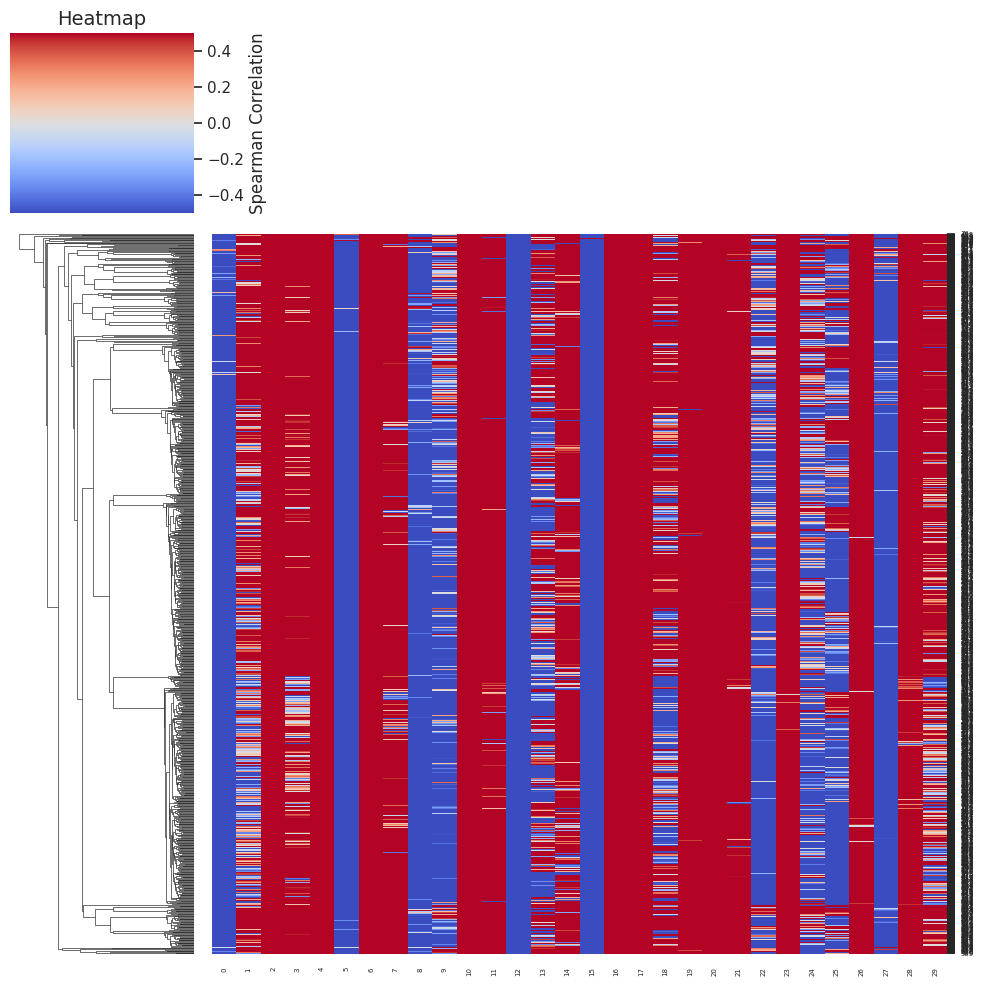

In [262]:
plt.figure(figsize=(30, 30))
sns.set(style="white")
g = sns.clustermap(
    clr_matrix,
    cmap="coolwarm",  # 颜色映射：蓝（负相关）-白（无相关）-红（正相关）
    square=True,  # 单元格为正方形
    vmin=-0.5,
    vmax=0.5,  # 颜色范围固定为[-1,1]（相关性范围）
    linewidths=0,  # 单元格边框宽度
    cbar_kws={"label": "Spearman Correlation"},  # 颜色条标签
    row_cluster=True,  # 对行进行聚类
    col_cluster=False,  # 对列进行聚类
    yticklabels=True,
    xticklabels=True,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    fontsize=5,  # 与Y轴一致
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    fontsize=5,  # 与Y轴一致
)
plt.title("Heatmap", fontsize=14)
plt.tight_layout()  # 自动调整布局，避免标签重叠

# plt.savefig('gene_correlation_heatmap.png', dpi=300, bbox_inches='tight')  # 保存为高清图片
plt.show()